<a href="https://colab.research.google.com/github/takaakisasaki/DepMap-based-in-silico-screening-of-synthetic-lethal-paralogs/blob/main/comprehensive_paralog_scanner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Comprehensive Paralog Synthetic Lethality Scanner
## DepMap Public 25Q3 - All Categories Analysis

---

**作業ディレクトリ**: `/content/drive/MyDrive/2026/SR_paralog`

### カテゴリー
1. **Chromatin Remodeling** - SWI/SNF, PRC, NuRD, etc.
2. **Metabolism** - MTAP/PRMT5, ENO1/ENO2, etc.
3. **DNA Damage Repair** - BRCA, RAD, PARP, etc.
4. **Splicing Factors** - SF3B, U2AF, etc.
5. **Transcription Factors** - MYC, TEAD, etc.
6. **Kinases** - CDK, MAPK, etc.
7. **Ubiquitin System** - E3 ligases, DUBs, etc.
8. **Cell Cycle** - Cyclins, CDKs, etc.
9. **RNA Processing** - DEAD-box helicases, etc.
10. **Mitochondria** - Respiratory chain, etc.
11. **Cytoskeleton** - Actins, Tubulins, etc.
12. **Signaling** - RTKs, GPCRs, etc.

---
## 1. 環境セットアップ

In [ ]:
# Google Drive マウント
from google.colab import drive
drive.mount('/content/drive')

# 作業ディレクトリ設定
WORK_DIR = '/content/drive/MyDrive/2026/SR_paralog'
DATA_DIR = f'{WORK_DIR}/depmap_25q3'

import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(f'{WORK_DIR}/results', exist_ok=True)
os.makedirs(f'{WORK_DIR}/results/by_category', exist_ok=True)

print(f"Work directory: {WORK_DIR}")
print(f"Data directory: {DATA_DIR}")

Mounted at /content/drive
Work directory: /content/drive/MyDrive/2026/SR_paralog
Data directory: /content/drive/MyDrive/2026/SR_paralog/depmap_25q3


In [ ]:
# パッケージインストール
!pip install statsmodels -q

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import false_discovery_control
import statsmodels.api as sm
from typing import List, Dict, Optional
from dataclasses import dataclass
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

print("✅ Setup complete!")

✅ Setup complete!


---
## 2. 包括的パラログデータベース

In [ ]:
@dataclass
class ParalogPair:
    """パラログペア"""
    gene_a: str           # ドライバー遺伝子
    gene_b: str           # ターゲット遺伝子
    category: str         # 大カテゴリー
    subcategory: str      # サブカテゴリー
    evidence: str         # エビデンスレベル
    pmid: str = ""        # 参考文献


# ============================================================================
# 包括的パラログデータベース
# ============================================================================

PARALOG_DATABASE = [
    # ==========================================================================
    # 1. CHROMATIN REMODELING
    # ==========================================================================
    # SWI/SNF Complex
    ParalogPair("SMARCA4", "SMARCA2", "Chromatin", "SWI/SNF", "published", "26552009"),
    ParalogPair("SMARCA2", "SMARCA4", "Chromatin", "SWI/SNF", "published", "26552009"),
    ParalogPair("ARID1A", "ARID1B", "Chromatin", "SWI/SNF", "published", "24520176"),
    ParalogPair("ARID1B", "ARID1A", "Chromatin", "SWI/SNF", "published", "24520176"),
    ParalogPair("ARID2", "ARID1A", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("BRD9", "BRD7", "Chromatin", "SWI/SNF", "published", "31253568"),
    ParalogPair("BRD7", "BRD9", "Chromatin", "SWI/SNF", "published", "31253568"),
    ParalogPair("SMARCC1", "SMARCC2", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("SMARCC2", "SMARCC1", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("SMARCD1", "SMARCD2", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("SMARCD2", "SMARCD3", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("PBRM1", "ARID2", "Chromatin", "SWI/SNF", "published", "29562155"),
    ParalogPair("DPF1", "DPF2", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("DPF2", "DPF3", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("BCL7A", "BCL7B", "Chromatin", "SWI/SNF", "predicted", ""),
    ParalogPair("BCL7B", "BCL7C", "Chromatin", "SWI/SNF", "predicted", ""),

    # PRC Complex
    ParalogPair("EZH1", "EZH2", "Chromatin", "PRC", "published", "31068699"),
    ParalogPair("EZH2", "EZH1", "Chromatin", "PRC", "published", "31068699"),
    ParalogPair("CBX2", "CBX4", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("CBX4", "CBX8", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("CBX7", "CBX8", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("PCGF1", "PCGF2", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("PCGF2", "PCGF4", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("PCGF4", "PCGF5", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("RING1", "RNF2", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("RNF2", "RING1", "Chromatin", "PRC", "predicted", ""),
    ParalogPair("SUZ12", "EED", "Chromatin", "PRC", "predicted", ""),

    # NuRD Complex
    ParalogPair("CHD3", "CHD4", "Chromatin", "NuRD", "predicted", ""),
    ParalogPair("CHD4", "CHD5", "Chromatin", "NuRD", "predicted", ""),
    ParalogPair("MTA1", "MTA2", "Chromatin", "NuRD", "predicted", ""),
    ParalogPair("MTA2", "MTA3", "Chromatin", "NuRD", "predicted", ""),
    ParalogPair("HDAC1", "HDAC2", "Chromatin", "NuRD", "published", ""),
    ParalogPair("HDAC2", "HDAC1", "Chromatin", "NuRD", "published", ""),
    ParalogPair("GATAD2A", "GATAD2B", "Chromatin", "NuRD", "predicted", ""),
    ParalogPair("MBD2", "MBD3", "Chromatin", "NuRD", "predicted", ""),

    # HAT/HDAC
    ParalogPair("CREBBP", "EP300", "Chromatin", "HAT", "published", "27571770"),
    ParalogPair("EP300", "CREBBP", "Chromatin", "HAT", "published", "27571770"),
    ParalogPair("KAT2A", "KAT2B", "Chromatin", "HAT", "predicted", ""),
    ParalogPair("KAT6A", "KAT6B", "Chromatin", "HAT", "predicted", ""),
    ParalogPair("HDAC3", "HDAC8", "Chromatin", "HDAC", "predicted", ""),

    # Histone Methyltransferases
    ParalogPair("KMT2A", "KMT2B", "Chromatin", "HMT", "predicted", ""),
    ParalogPair("KMT2C", "KMT2D", "Chromatin", "HMT", "published", ""),
    ParalogPair("SETD1A", "SETD1B", "Chromatin", "HMT", "predicted", ""),
    ParalogPair("NSD1", "NSD2", "Chromatin", "HMT", "predicted", ""),
    ParalogPair("NSD2", "NSD3", "Chromatin", "HMT", "predicted", ""),

    # Histone Demethylases
    ParalogPair("KDM1A", "KDM1B", "Chromatin", "KDM", "predicted", ""),
    ParalogPair("KDM4A", "KDM4B", "Chromatin", "KDM", "predicted", ""),
    ParalogPair("KDM5A", "KDM5B", "Chromatin", "KDM", "predicted", ""),
    ParalogPair("KDM6A", "KDM6B", "Chromatin", "KDM", "published", ""),

    # Cohesin
    ParalogPair("STAG1", "STAG2", "Chromatin", "Cohesin", "published", "33007256"),
    ParalogPair("STAG2", "STAG1", "Chromatin", "Cohesin", "published", "33007256"),

    # DNA Methylation
    ParalogPair("DNMT1", "DNMT3A", "Chromatin", "DNA_methylation", "predicted", ""),
    ParalogPair("DNMT3A", "DNMT3B", "Chromatin", "DNA_methylation", "predicted", ""),
    ParalogPair("TET1", "TET2", "Chromatin", "DNA_methylation", "predicted", ""),
    ParalogPair("TET2", "TET3", "Chromatin", "DNA_methylation", "predicted", ""),

    # ISWI/INO80
    ParalogPair("SMARCA1", "SMARCA5", "Chromatin", "ISWI", "predicted", ""),
    ParalogPair("SMARCA5", "SMARCA1", "Chromatin", "ISWI", "predicted", ""),
    ParalogPair("BAZ1A", "BAZ1B", "Chromatin", "ISWI", "predicted", ""),
    ParalogPair("BAZ2A", "BAZ2B", "Chromatin", "ISWI", "predicted", ""),
    ParalogPair("INO80", "SRCAP", "Chromatin", "INO80", "predicted", ""),

    # ==========================================================================
    # 2. METABOLISM
    # ==========================================================================
    # One-carbon metabolism
    ParalogPair("MTAP", "PRMT5", "Metabolism", "Methionine_salvage", "published", "27416917"),
    ParalogPair("MAT1A", "MAT2A", "Metabolism", "Methionine_salvage", "published", ""),
    ParalogPair("MAT2A", "MAT2B", "Metabolism", "Methionine_salvage", "predicted", ""),

    # Glycolysis
    ParalogPair("ENO1", "ENO2", "Metabolism", "Glycolysis", "published", "28178239"),
    ParalogPair("ENO2", "ENO3", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("PKM", "PKLR", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("ALDOA", "ALDOB", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("ALDOB", "ALDOC", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("GAPDH", "GAPDHS", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("HK1", "HK2", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("HK2", "HK3", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("PFKM", "PFKP", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("PFKP", "PFKL", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("LDHA", "LDHB", "Metabolism", "Glycolysis", "predicted", ""),
    ParalogPair("LDHB", "LDHC", "Metabolism", "Glycolysis", "predicted", ""),

    # TCA Cycle
    ParalogPair("IDH1", "IDH2", "Metabolism", "TCA_cycle", "predicted", ""),
    ParalogPair("IDH2", "IDH3A", "Metabolism", "TCA_cycle", "predicted", ""),
    ParalogPair("MDH1", "MDH2", "Metabolism", "TCA_cycle", "predicted", ""),
    ParalogPair("FH", "SDHA", "Metabolism", "TCA_cycle", "predicted", ""),
    ParalogPair("CS", "ACLY", "Metabolism", "TCA_cycle", "predicted", ""),

    # Glutamine metabolism
    ParalogPair("GLS", "GLS2", "Metabolism", "Glutamine", "predicted", ""),
    ParalogPair("GLUL", "GLUD1", "Metabolism", "Glutamine", "predicted", ""),
    ParalogPair("GLUD1", "GLUD2", "Metabolism", "Glutamine", "predicted", ""),
    ParalogPair("GOT1", "GOT2", "Metabolism", "Glutamine", "predicted", ""),

    # Lipid metabolism
    ParalogPair("FASN", "ACACA", "Metabolism", "Lipid", "predicted", ""),
    ParalogPair("ACACA", "ACACB", "Metabolism", "Lipid", "predicted", ""),
    ParalogPair("SCD", "SCD5", "Metabolism", "Lipid", "predicted", ""),
    ParalogPair("HMGCR", "HMGCS1", "Metabolism", "Lipid", "predicted", ""),

    # Nucleotide metabolism
    ParalogPair("TYMS", "DHFR", "Metabolism", "Nucleotide", "predicted", ""),
    ParalogPair("RRM1", "RRM2", "Metabolism", "Nucleotide", "predicted", ""),
    ParalogPair("RRM2", "RRM2B", "Metabolism", "Nucleotide", "predicted", ""),
    ParalogPair("DHODH", "UMPS", "Metabolism", "Nucleotide", "predicted", ""),
    ParalogPair("CAD", "DHODH", "Metabolism", "Nucleotide", "predicted", ""),
    ParalogPair("IMPDH1", "IMPDH2", "Metabolism", "Nucleotide", "predicted", ""),

    # ==========================================================================
    # 3. DNA DAMAGE REPAIR
    # ==========================================================================
    # Homologous Recombination
    ParalogPair("BRCA1", "BRCA2", "DNA_Repair", "HR", "published", ""),
    ParalogPair("BRCA2", "PALB2", "DNA_Repair", "HR", "published", ""),
    ParalogPair("RAD51", "RAD51B", "DNA_Repair", "HR", "predicted", ""),
    ParalogPair("RAD51B", "RAD51C", "DNA_Repair", "HR", "predicted", ""),
    ParalogPair("RAD51C", "RAD51D", "DNA_Repair", "HR", "predicted", ""),
    ParalogPair("RAD54L", "RAD54B", "DNA_Repair", "HR", "predicted", ""),
    ParalogPair("XRCC2", "XRCC3", "DNA_Repair", "HR", "predicted", ""),

    # PARP family
    ParalogPair("PARP1", "PARP2", "DNA_Repair", "PARP", "published", ""),
    ParalogPair("PARP2", "PARP3", "DNA_Repair", "PARP", "predicted", ""),

    # Base Excision Repair
    ParalogPair("OGG1", "MUTYH", "DNA_Repair", "BER", "predicted", ""),
    ParalogPair("APEX1", "APEX2", "DNA_Repair", "BER", "predicted", ""),
    ParalogPair("XRCC1", "LIG3", "DNA_Repair", "BER", "predicted", ""),
    ParalogPair("POLB", "POLL", "DNA_Repair", "BER", "predicted", ""),

    # Mismatch Repair
    ParalogPair("MLH1", "MLH3", "DNA_Repair", "MMR", "predicted", ""),
    ParalogPair("MSH2", "MSH6", "DNA_Repair", "MMR", "predicted", ""),
    ParalogPair("MSH3", "MSH6", "DNA_Repair", "MMR", "predicted", ""),
    ParalogPair("PMS1", "PMS2", "DNA_Repair", "MMR", "predicted", ""),

    # Non-homologous End Joining
    ParalogPair("XRCC4", "XRCC5", "DNA_Repair", "NHEJ", "predicted", ""),
    ParalogPair("XRCC5", "XRCC6", "DNA_Repair", "NHEJ", "predicted", ""),
    ParalogPair("LIG4", "LIG3", "DNA_Repair", "NHEJ", "predicted", ""),
    ParalogPair("DCLRE1C", "PRKDC", "DNA_Repair", "NHEJ", "predicted", ""),

    # Fanconi Anemia
    ParalogPair("FANCA", "FANCC", "DNA_Repair", "FA", "predicted", ""),
    ParalogPair("FANCD2", "FANCI", "DNA_Repair", "FA", "published", ""),
    ParalogPair("FANCM", "FANCJ", "DNA_Repair", "FA", "predicted", ""),

    # ATM/ATR pathway
    ParalogPair("ATM", "ATR", "DNA_Repair", "Checkpoint", "published", ""),
    ParalogPair("CHEK1", "CHEK2", "DNA_Repair", "Checkpoint", "published", ""),

    # ==========================================================================
    # 4. SPLICING FACTORS
    # ==========================================================================
    ParalogPair("SF3B1", "SF3B2", "Splicing", "SF3B", "predicted", ""),
    ParalogPair("SF3B2", "SF3B3", "Splicing", "SF3B", "predicted", ""),
    ParalogPair("U2AF1", "U2AF2", "Splicing", "U2AF", "published", ""),
    ParalogPair("SRSF1", "SRSF2", "Splicing", "SRSF", "predicted", ""),
    ParalogPair("SRSF2", "SRSF3", "Splicing", "SRSF", "predicted", ""),
    ParalogPair("SRSF3", "SRSF6", "Splicing", "SRSF", "predicted", ""),
    ParalogPair("HNRNPA1", "HNRNPA2B1", "Splicing", "hnRNP", "predicted", ""),
    ParalogPair("HNRNPC", "HNRNPD", "Splicing", "hnRNP", "predicted", ""),
    ParalogPair("HNRNPH1", "HNRNPH2", "Splicing", "hnRNP", "predicted", ""),
    ParalogPair("HNRNPK", "HNRNPL", "Splicing", "hnRNP", "predicted", ""),
    ParalogPair("PRPF8", "PRPF31", "Splicing", "PRP", "predicted", ""),
    ParalogPair("SNRPA", "SNRPB", "Splicing", "snRNP", "predicted", ""),
    ParalogPair("SNRPD1", "SNRPD2", "Splicing", "snRNP", "predicted", ""),
    ParalogPair("SNRPD2", "SNRPD3", "Splicing", "snRNP", "predicted", ""),
    ParalogPair("RBM10", "RBM5", "Splicing", "RBM", "predicted", ""),
    ParalogPair("RBMX", "RBMXL1", "Splicing", "RBM", "predicted", ""),

    # ==========================================================================
    # 5. TRANSCRIPTION FACTORS
    # ==========================================================================
    ParalogPair("MYC", "MYCN", "Transcription", "MYC", "published", ""),
    ParalogPair("MYCN", "MYCL", "Transcription", "MYC", "predicted", ""),
    ParalogPair("MAX", "MXD1", "Transcription", "MYC", "predicted", ""),
    ParalogPair("TEAD1", "TEAD2", "Transcription", "TEAD", "predicted", ""),
    ParalogPair("TEAD2", "TEAD3", "Transcription", "TEAD", "predicted", ""),
    ParalogPair("TEAD3", "TEAD4", "Transcription", "TEAD", "predicted", ""),
    ParalogPair("YAP1", "WWTR1", "Transcription", "Hippo", "published", ""),
    ParalogPair("SMAD2", "SMAD3", "Transcription", "SMAD", "predicted", ""),
    ParalogPair("SMAD3", "SMAD4", "Transcription", "SMAD", "predicted", ""),
    ParalogPair("RUNX1", "RUNX2", "Transcription", "RUNX", "predicted", ""),
    ParalogPair("RUNX2", "RUNX3", "Transcription", "RUNX", "predicted", ""),
    ParalogPair("GATA1", "GATA2", "Transcription", "GATA", "predicted", ""),
    ParalogPair("GATA2", "GATA3", "Transcription", "GATA", "predicted", ""),
    ParalogPair("GATA3", "GATA4", "Transcription", "GATA", "predicted", ""),
    ParalogPair("FOXA1", "FOXA2", "Transcription", "FOX", "predicted", ""),
    ParalogPair("FOXM1", "FOXO1", "Transcription", "FOX", "predicted", ""),
    ParalogPair("FOXO1", "FOXO3", "Transcription", "FOX", "predicted", ""),
    ParalogPair("TP53", "TP63", "Transcription", "p53_family", "published", ""),
    ParalogPair("TP63", "TP73", "Transcription", "p53_family", "predicted", ""),
    ParalogPair("RB1", "RBL1", "Transcription", "RB_family", "predicted", ""),
    ParalogPair("RBL1", "RBL2", "Transcription", "RB_family", "predicted", ""),
    ParalogPair("E2F1", "E2F2", "Transcription", "E2F", "predicted", ""),
    ParalogPair("E2F2", "E2F3", "Transcription", "E2F", "predicted", ""),
    ParalogPair("E2F3", "E2F4", "Transcription", "E2F", "predicted", ""),
    ParalogPair("NFE2L2", "NFE2L1", "Transcription", "NRF", "predicted", ""),
    ParalogPair("HIF1A", "EPAS1", "Transcription", "HIF", "predicted", ""),
    ParalogPair("STAT1", "STAT2", "Transcription", "STAT", "predicted", ""),
    ParalogPair("STAT3", "STAT5A", "Transcription", "STAT", "predicted", ""),
    ParalogPair("STAT5A", "STAT5B", "Transcription", "STAT", "predicted", ""),

    # ==========================================================================
    # 6. KINASES
    # ==========================================================================
    # CDKs
    ParalogPair("CDK1", "CDK2", "Kinase", "CDK", "predicted", ""),
    ParalogPair("CDK2", "CDK4", "Kinase", "CDK", "predicted", ""),
    ParalogPair("CDK4", "CDK6", "Kinase", "CDK", "published", ""),
    ParalogPair("CDK7", "CDK9", "Kinase", "CDK", "predicted", ""),
    ParalogPair("CDK12", "CDK13", "Kinase", "CDK", "predicted", ""),

    # MAPK pathway
    ParalogPair("MAPK1", "MAPK3", "Kinase", "MAPK", "predicted", ""),
    ParalogPair("MAP2K1", "MAP2K2", "Kinase", "MAPK", "predicted", ""),
    ParalogPair("MAP3K1", "MAP3K2", "Kinase", "MAPK", "predicted", ""),
    ParalogPair("BRAF", "RAF1", "Kinase", "RAF", "published", ""),
    ParalogPair("RAF1", "ARAF", "Kinase", "RAF", "predicted", ""),

    # PI3K pathway
    ParalogPair("PIK3CA", "PIK3CB", "Kinase", "PI3K", "predicted", ""),
    ParalogPair("PIK3CB", "PIK3CD", "Kinase", "PI3K", "predicted", ""),
    ParalogPair("AKT1", "AKT2", "Kinase", "AKT", "predicted", ""),
    ParalogPair("AKT2", "AKT3", "Kinase", "AKT", "predicted", ""),
    ParalogPair("MTOR", "RPTOR", "Kinase", "mTOR", "predicted", ""),
    ParalogPair("TSC1", "TSC2", "Kinase", "mTOR", "predicted", ""),

    # Receptor Tyrosine Kinases
    ParalogPair("EGFR", "ERBB2", "Kinase", "RTK", "predicted", ""),
    ParalogPair("ERBB2", "ERBB3", "Kinase", "RTK", "published", ""),
    ParalogPair("ERBB3", "ERBB4", "Kinase", "RTK", "predicted", ""),
    ParalogPair("FGFR1", "FGFR2", "Kinase", "RTK", "predicted", ""),
    ParalogPair("FGFR2", "FGFR3", "Kinase", "RTK", "predicted", ""),
    ParalogPair("FGFR3", "FGFR4", "Kinase", "RTK", "predicted", ""),
    ParalogPair("MET", "MST1R", "Kinase", "RTK", "predicted", ""),
    ParalogPair("IGF1R", "INSR", "Kinase", "RTK", "predicted", ""),

    # Aurora kinases
    ParalogPair("AURKA", "AURKB", "Kinase", "Aurora", "published", ""),
    ParalogPair("AURKB", "AURKC", "Kinase", "Aurora", "predicted", ""),

    # PLK
    ParalogPair("PLK1", "PLK2", "Kinase", "PLK", "predicted", ""),
    ParalogPair("PLK2", "PLK3", "Kinase", "PLK", "predicted", ""),
    ParalogPair("PLK3", "PLK4", "Kinase", "PLK", "predicted", ""),

    # SRC family
    ParalogPair("SRC", "YES1", "Kinase", "SRC", "predicted", ""),
    ParalogPair("YES1", "FYN", "Kinase", "SRC", "predicted", ""),
    ParalogPair("LYN", "HCK", "Kinase", "SRC", "predicted", ""),

    # ==========================================================================
    # 7. UBIQUITIN SYSTEM
    # ==========================================================================
    # E3 ligases
    ParalogPair("MDM2", "MDM4", "Ubiquitin", "E3_ligase", "published", ""),
    ParalogPair("FBXW7", "FBXW11", "Ubiquitin", "E3_ligase", "predicted", ""),
    ParalogPair("CUL1", "CUL2", "Ubiquitin", "Cullin", "predicted", ""),
    ParalogPair("CUL2", "CUL3", "Ubiquitin", "Cullin", "predicted", ""),
    ParalogPair("CUL3", "CUL4A", "Ubiquitin", "Cullin", "predicted", ""),
    ParalogPair("CUL4A", "CUL4B", "Ubiquitin", "Cullin", "predicted", ""),
    ParalogPair("BIRC2", "BIRC3", "Ubiquitin", "E3_ligase", "predicted", ""),
    ParalogPair("TRIM24", "TRIM28", "Ubiquitin", "TRIM", "predicted", ""),
    ParalogPair("TRIM28", "TRIM33", "Ubiquitin", "TRIM", "predicted", ""),

    # DUBs
    ParalogPair("USP1", "USP7", "Ubiquitin", "DUB", "predicted", ""),
    ParalogPair("USP7", "USP8", "Ubiquitin", "DUB", "predicted", ""),
    ParalogPair("USP14", "USP15", "Ubiquitin", "DUB", "predicted", ""),
    ParalogPair("USP28", "USP25", "Ubiquitin", "DUB", "predicted", ""),

    # ==========================================================================
    # 8. CELL CYCLE
    # ==========================================================================
    # Cyclins
    ParalogPair("CCNA1", "CCNA2", "Cell_Cycle", "Cyclin", "predicted", ""),
    ParalogPair("CCNB1", "CCNB2", "Cell_Cycle", "Cyclin", "predicted", ""),
    ParalogPair("CCND1", "CCND2", "Cell_Cycle", "Cyclin", "predicted", ""),
    ParalogPair("CCND2", "CCND3", "Cell_Cycle", "Cyclin", "predicted", ""),
    ParalogPair("CCNE1", "CCNE2", "Cell_Cycle", "Cyclin", "predicted", ""),

    # CDK inhibitors
    ParalogPair("CDKN1A", "CDKN1B", "Cell_Cycle", "CDKI", "predicted", ""),
    ParalogPair("CDKN1B", "CDKN1C", "Cell_Cycle", "CDKI", "predicted", ""),
    ParalogPair("CDKN2A", "CDKN2B", "Cell_Cycle", "CDKI", "published", ""),
    ParalogPair("CDKN2B", "CDKN2C", "Cell_Cycle", "CDKI", "predicted", ""),
    ParalogPair("CDKN2C", "CDKN2D", "Cell_Cycle", "CDKI", "predicted", ""),

    # Mitotic checkpoint
    ParalogPair("BUB1", "BUB1B", "Cell_Cycle", "SAC", "predicted", ""),
    ParalogPair("MAD1L1", "MAD2L1", "Cell_Cycle", "SAC", "predicted", ""),
    ParalogPair("CDC20", "FZR1", "Cell_Cycle", "APC", "predicted", ""),
    ParalogPair("ANAPC1", "ANAPC2", "Cell_Cycle", "APC", "predicted", ""),

    # ==========================================================================
    # 9. RNA PROCESSING
    # ==========================================================================
    # DEAD-box helicases
    ParalogPair("DDX3X", "DDX3Y", "RNA_Processing", "DDX", "predicted", ""),
    ParalogPair("DDX5", "DDX17", "RNA_Processing", "DDX", "predicted", ""),
    ParalogPair("DDX41", "DDX46", "RNA_Processing", "DDX", "predicted", ""),
    ParalogPair("DHX9", "DHX36", "RNA_Processing", "DDX", "predicted", ""),

    # RNA polymerase
    ParalogPair("POLR2A", "POLR2B", "RNA_Processing", "RNAP", "predicted", ""),

    # Translation initiation
    ParalogPair("EIF4A1", "EIF4A2", "RNA_Processing", "Translation", "predicted", ""),
    ParalogPair("EIF4E", "EIF4EBP1", "RNA_Processing", "Translation", "predicted", ""),
    ParalogPair("EIF2S1", "EIF2S2", "RNA_Processing", "Translation", "predicted", ""),
    ParalogPair("EIF3A", "EIF3B", "RNA_Processing", "Translation", "predicted", ""),

    # Ribosome
    ParalogPair("RPL5", "RPL11", "RNA_Processing", "Ribosome", "predicted", ""),
    ParalogPair("RPS6", "RPS14", "RNA_Processing", "Ribosome", "predicted", ""),

    # ==========================================================================
    # 10. MITOCHONDRIA
    # ==========================================================================
    # Respiratory chain
    ParalogPair("NDUFA1", "NDUFA2", "Mitochondria", "Complex_I", "predicted", ""),
    ParalogPair("NDUFS1", "NDUFS2", "Mitochondria", "Complex_I", "predicted", ""),
    ParalogPair("UQCRC1", "UQCRC2", "Mitochondria", "Complex_III", "predicted", ""),
    ParalogPair("COX4I1", "COX4I2", "Mitochondria", "Complex_IV", "predicted", ""),
    ParalogPair("COX5A", "COX5B", "Mitochondria", "Complex_IV", "predicted", ""),
    ParalogPair("ATP5F1A", "ATP5F1B", "Mitochondria", "Complex_V", "predicted", ""),

    # Mitochondrial dynamics
    ParalogPair("MFN1", "MFN2", "Mitochondria", "Fusion", "predicted", ""),
    ParalogPair("DRP1", "OPA1", "Mitochondria", "Fission", "predicted", ""),

    # Apoptosis
    ParalogPair("BCL2", "BCL2L1", "Mitochondria", "Apoptosis", "published", ""),
    ParalogPair("BCL2L1", "MCL1", "Mitochondria", "Apoptosis", "published", ""),
    ParalogPair("BAX", "BAK1", "Mitochondria", "Apoptosis", "published", ""),
    ParalogPair("BID", "BIM", "Mitochondria", "Apoptosis", "predicted", ""),

    # ==========================================================================
    # 11. CYTOSKELETON
    # ==========================================================================
    # Actin
    ParalogPair("ACTB", "ACTG1", "Cytoskeleton", "Actin", "predicted", ""),
    ParalogPair("ACTA1", "ACTA2", "Cytoskeleton", "Actin", "predicted", ""),

    # Tubulin
    ParalogPair("TUBA1A", "TUBA1B", "Cytoskeleton", "Tubulin", "predicted", ""),
    ParalogPair("TUBB", "TUBB4A", "Cytoskeleton", "Tubulin", "predicted", ""),
    ParalogPair("TUBB4A", "TUBB4B", "Cytoskeleton", "Tubulin", "predicted", ""),

    # Motor proteins
    ParalogPair("KIF2A", "KIF2C", "Cytoskeleton", "Kinesin", "predicted", ""),
    ParalogPair("KIF11", "KIF15", "Cytoskeleton", "Kinesin", "predicted", ""),
    ParalogPair("DYNC1H1", "DYNC2H1", "Cytoskeleton", "Dynein", "predicted", ""),

    # ==========================================================================
    # 12. SIGNALING
    # ==========================================================================
    # Wnt pathway
    ParalogPair("CTNNB1", "JUP", "Signaling", "Wnt", "predicted", ""),
    ParalogPair("APC", "APC2", "Signaling", "Wnt", "predicted", ""),
    ParalogPair("GSK3A", "GSK3B", "Signaling", "Wnt", "predicted", ""),
    ParalogPair("DVL1", "DVL2", "Signaling", "Wnt", "predicted", ""),
    ParalogPair("DVL2", "DVL3", "Signaling", "Wnt", "predicted", ""),

    # Notch pathway
    ParalogPair("NOTCH1", "NOTCH2", "Signaling", "Notch", "predicted", ""),
    ParalogPair("NOTCH2", "NOTCH3", "Signaling", "Notch", "predicted", ""),
    ParalogPair("NOTCH3", "NOTCH4", "Signaling", "Notch", "predicted", ""),
    ParalogPair("JAG1", "JAG2", "Signaling", "Notch", "predicted", ""),
    ParalogPair("DLL1", "DLL4", "Signaling", "Notch", "predicted", ""),

    # Hedgehog pathway
    ParalogPair("GLI1", "GLI2", "Signaling", "Hedgehog", "predicted", ""),
    ParalogPair("GLI2", "GLI3", "Signaling", "Hedgehog", "predicted", ""),

    # NF-kB pathway
    ParalogPair("RELA", "RELB", "Signaling", "NFkB", "predicted", ""),
    ParalogPair("NFKB1", "NFKB2", "Signaling", "NFkB", "predicted", ""),
    ParalogPair("IKBKA", "IKBKB", "Signaling", "NFkB", "predicted", ""),

    # RAS family
    ParalogPair("KRAS", "NRAS", "Signaling", "RAS", "published", ""),
    ParalogPair("NRAS", "HRAS", "Signaling", "RAS", "predicted", ""),
    ParalogPair("RAC1", "RAC2", "Signaling", "RAS", "predicted", ""),
    ParalogPair("RHOA", "RHOB", "Signaling", "RAS", "predicted", ""),
    ParalogPair("RHOB", "RHOC", "Signaling", "RAS", "predicted", ""),
]

print(f"Total paralog pairs in database: {len(PARALOG_DATABASE)}")

# カテゴリー集計
category_df = pd.DataFrame([(p.category, p.subcategory) for p in PARALOG_DATABASE],
                           columns=['Category', 'Subcategory'])
print("\n📊 Pairs by Category:")
display(category_df['Category'].value_counts().to_frame('count'))

print("\n📊 Pairs by Subcategory (top 20):")
display(category_df['Subcategory'].value_counts().head(20).to_frame('count'))

Total paralog pairs in database: 275

📊 Pairs by Category:


,count
Category,
Chromatin,60
Metabolism,34
Kinase,32
Transcription,29
DNA_Repair,26
Signaling,20
Splicing,16
Cell_Cycle,14
Ubiquitin,13



📊 Pairs by Subcategory (top 20):


,count
Subcategory,
SWI/SNF,16
Glycolysis,12
PRC,11
NuRD,8
RTK,8
HR,7
Nucleotide,6
TCA_cycle,5
CDK,5


---
## 3. データローダー & 解析クラス

In [ ]:
class DepMap25Q3Loader:
    """DepMap Public 25Q3 データローダー"""

    FILE_MAPPING = {
        'crispr': 'CRISPRGeneEffect.csv',
        'model': 'Model.csv',
        'mutations': 'OmicsSomaticMutations.csv',
        'expression': 'OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv',
        'cnv': 'OmicsCNGene.csv',
    }

    def __init__(self, data_dir: str):
        self.data_dir = Path(data_dir)
        self.crispr = None
        self.model = None
        self.mutations = None
        self.expression = None
        self.cnv = None

    def load_all(self):
        print("="*60)
        print("Loading DepMap 25Q3 data...")
        print("="*60)

        # CRISPR
        print("\n📊 Loading CRISPR...")
        self.crispr = pd.read_csv(self.data_dir / self.FILE_MAPPING['crispr'], index_col=0)
        self.crispr.columns = [c.split(' ')[0] for c in self.crispr.columns]
        print(f"   ✅ {self.crispr.shape[0]} × {self.crispr.shape[1]}")

        # Model
        print("\n📋 Loading Model...")
        self.model = pd.read_csv(self.data_dir / self.FILE_MAPPING['model']).set_index('ModelID')
        print(f"   ✅ {len(self.model)} cell lines")

        # Mutations
        print("\n🧬 Loading Mutations...")
        self.mutations = pd.read_csv(self.data_dir / self.FILE_MAPPING['mutations'], low_memory=False)
        print(f"   ✅ {len(self.mutations)} mutations")

        # Expression
        print("\n📈 Loading Expression...")
        expr_raw = pd.read_csv(self.data_dir / self.FILE_MAPPING['expression'])
        self.expression = expr_raw.set_index('ModelID')
        meta_cols = ['Unnamed: 0', 'SequencingID', 'IsDefaultEntryForModel', 'ModelConditionID', 'IsDefaultEntryForMC']
        self.expression = self.expression.drop(columns=[c for c in meta_cols if c in self.expression.columns])
        self.expression.columns = [c.split(' ')[0] for c in self.expression.columns]
        if self.expression.index.duplicated().any():
            self.expression = self.expression[~self.expression.index.duplicated(keep='first')]
        print(f"   ✅ {self.expression.shape[0]} × {self.expression.shape[1]}")

        # CNV (optional)
        cnv_path = self.data_dir / self.FILE_MAPPING['cnv']
        if cnv_path.exists():
            print("\n📉 Loading CNV...")
            self.cnv = pd.read_csv(cnv_path, index_col=0)
            self.cnv.columns = [c.split(' ')[0] for c in self.cnv.columns]
            print(f"   ✅ {self.cnv.shape[0]} × {self.cnv.shape[1]}")

        print("\n" + "="*60)
        return self

In [ ]:
class ConfounderAdjustedAnalyzer:
    """交絡補正付き解析クラス"""

    def __init__(self, loader):
        self.loader = loader

    def get_lof_status(self, gene):
        if self.loader.mutations is None:
            return pd.Series(dtype=bool)

        gene_muts = self.loader.mutations[self.loader.mutations['HugoSymbol'] == gene].copy()
        if len(gene_muts) == 0:
            return pd.Series([False] * len(self.loader.crispr), index=self.loader.crispr.index)

        lof_mask = pd.Series([False] * len(gene_muts), index=gene_muts.index)

        if 'VariantType' in gene_muts.columns and 'Ref' in gene_muts.columns:
            lof_mask |= ((gene_muts['VariantType'].isin(['deletion', 'insertion'])) &
                        (gene_muts['Ref'].str.len() != gene_muts['Alt'].str.len()))

        if 'ProveanPrediction' in gene_muts.columns:
            lof_mask |= (gene_muts['ProveanPrediction'] == 'Damaging')
        if 'AMClass' in gene_muts.columns:
            lof_mask |= gene_muts['AMClass'].str.contains('pathogenic', case=False, na=False)
        if 'AMPathogenicity' in gene_muts.columns:
            lof_mask |= (gene_muts['AMPathogenicity'].fillna(0) > 0.5)

        lof_lines = set(gene_muts[lof_mask]['ModelID'].unique())
        return pd.Series([line in lof_lines for line in self.loader.crispr.index],
                        index=self.loader.crispr.index)

    def get_low_expression_status(self, gene, percentile=25):
        if self.loader.expression is None or gene not in self.loader.expression.columns:
            return pd.Series([False] * len(self.loader.crispr), index=self.loader.crispr.index)
        expr = self.loader.expression[gene]
        threshold = np.nanpercentile(expr.dropna(), percentile)
        return pd.Series(expr <= threshold)

    def run_ols_analysis(self, driver, target, stratify_by="any", min_affected=5):
        if target not in self.loader.crispr.columns:
            return None

        data = pd.DataFrame({'dependency': self.loader.crispr[target]})

        if stratify_by == "any":
            lof = self.get_lof_status(driver)
            low_expr = self.get_low_expression_status(driver)
            data['driver_status'] = lof.fillna(False) | low_expr.fillna(False)
        elif stratify_by == "mutation":
            data['driver_status'] = self.get_lof_status(driver)
        else:
            data['driver_status'] = self.get_low_expression_status(driver)

        # Lineage
        if self.loader.model is not None and 'OncotreeLineage' in self.loader.model.columns:
            lineage = self.loader.model['OncotreeLineage'].reindex(data.index)
            for lin in lineage.value_counts().head(10).index:
                safe_name = f'lineage_{re.sub(r"[^a-zA-Z0-9]", "_", str(lin))}'
                data[safe_name] = (lineage == lin).astype(int)

        if self.loader.expression is not None and target in self.loader.expression.columns:
            data['target_expr'] = self.loader.expression[target].reindex(data.index)

        data = data.dropna()
        if len(data) < 20:
            return None

        n_affected = data['driver_status'].sum()
        if n_affected < min_affected or (len(data) - n_affected) < min_affected:
            return None

        covariates = [c for c in data.columns if c.startswith('lineage_') or c == 'target_expr']

        try:
            y = data['dependency'].values
            X = sm.add_constant(data[['driver_status'] + covariates].astype(float).values)
            model = sm.OLS(y, X).fit()

            return {
                'driver_gene': driver,
                'target_gene': target,
                'n_affected': int(n_affected),
                'n_unaffected': int(len(data) - n_affected),
                'raw_delta': data[data['driver_status']]['dependency'].mean() - data[~data['driver_status']]['dependency'].mean(),
                'adjusted_coef': model.params[1],
                'adjusted_pvalue': model.pvalues[1],
                'ci_lower': model.conf_int()[1, 0],
                'ci_upper': model.conf_int()[1, 1],
                'r_squared': model.rsquared,
            }
        except:
            return None

In [ ]:
class ComprehensiveParalogScanner:
    """全カテゴリー対応パラログスキャナー"""

    def __init__(self, loader):
        self.loader = loader
        self.analyzer = ConfounderAdjustedAnalyzer(loader)
        self.results = pd.DataFrame()
        self.results_by_category = {}

    def scan_all(self, pairs=None, stratify_by="any", min_affected=5, verbose=True):
        if pairs is None:
            pairs = PARALOG_DATABASE

        print(f"\n{'='*60}")
        print(f"Scanning {len(pairs)} paralog pairs...")
        print(f"{'='*60}")

        results = []
        for i, pair in enumerate(pairs):
            if verbose and (i + 1) % 20 == 0:
                print(f"  Progress: {i+1}/{len(pairs)}")

            result = self.analyzer.run_ols_analysis(pair.gene_a, pair.gene_b, stratify_by, min_affected)
            if result:
                result['category'] = pair.category
                result['subcategory'] = pair.subcategory
                result['evidence'] = pair.evidence
                result['pmid'] = pair.pmid
                results.append(result)

        df = pd.DataFrame(results)
        if len(df) > 0:
            df['fdr'] = false_discovery_control(df['adjusted_pvalue'], method='bh')
            df = df.sort_values('adjusted_pvalue')
            df['significant_fdr05'] = df['fdr'] < 0.05
            df['significant_fdr10'] = df['fdr'] < 0.10

        self.results = df

        # カテゴリー別に分割
        for cat in df['category'].unique():
            self.results_by_category[cat] = df[df['category'] == cat].copy()

        print(f"\n✅ Complete! {len(df)} pairs analyzed.")
        return df

    def scan_category(self, category, stratify_by="any", min_affected=5):
        """特定カテゴリーのみスキャン"""
        pairs = [p for p in PARALOG_DATABASE if p.category == category]
        return self.scan_all(pairs, stratify_by, min_affected)

    def get_summary(self):
        """カテゴリー別サマリー"""
        if len(self.results) == 0:
            return pd.DataFrame()

        return self.results.groupby('category').agg({
            'driver_gene': 'count',
            'significant_fdr05': 'sum',
            'significant_fdr10': 'sum',
            'adjusted_coef': 'mean',
            'adjusted_pvalue': 'min',
        }).rename(columns={
            'driver_gene': 'n_pairs',
            'significant_fdr05': 'sig_fdr05',
            'significant_fdr10': 'sig_fdr10',
            'adjusted_coef': 'mean_effect',
            'adjusted_pvalue': 'best_pval',
        }).sort_values('sig_fdr10', ascending=False)

---
## 4. 可視化関数

In [ ]:
def plot_volcano_by_category(results, save_dir=None):
    """カテゴリー別Volcano plot"""
    categories = results['category'].unique()
    n_cat = len(categories)
    n_cols = 3
    n_rows = (n_cat + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten()

    for i, cat in enumerate(categories):
        ax = axes[i]
        df = results[results['category'] == cat].copy()
        df['neg_log_p'] = -np.log10(df['adjusted_pvalue'])

        colors = ['red' if (fdr < 0.05 and c < 0) else 'orange' if (fdr < 0.1 and c < 0) else 'lightgray'
                  for fdr, c in zip(df['fdr'], df['adjusted_coef'])]

        ax.scatter(df['adjusted_coef'], df['neg_log_p'], c=colors, alpha=0.6, s=50)
        ax.axhline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.3)
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
        ax.set_title(f"{cat}\n(n={len(df)}, sig={df['significant_fdr10'].sum()})")
        ax.set_xlabel('Adjusted Coef')
        ax.set_ylabel('-log10(p)')

        # Top hits ラベル
        for _, row in df[df['fdr'] < 0.1].nsmallest(3, 'adjusted_pvalue').iterrows():
            ax.annotate(f"{row['driver_gene']}→{row['target_gene']}",
                       (row['adjusted_coef'], row['neg_log_p']), fontsize=6)

    # 余白を非表示
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/volcano_by_category.png", dpi=150, bbox_inches='tight')
        print(f"Saved: {save_dir}/volcano_by_category.png")
    plt.show()


def plot_category_summary(results, save_dir=None):
    """カテゴリー別サマリーバーチャート"""
    summary = results.groupby('category').agg({
        'driver_gene': 'count',
        'significant_fdr05': 'sum',
        'significant_fdr10': 'sum',
    }).rename(columns={'driver_gene': 'total'})
    summary = summary.sort_values('significant_fdr10', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    y = range(len(summary))
    ax.barh(y, summary['total'], color='lightgray', label='Total tested')
    ax.barh(y, summary['significant_fdr10'], color='orange', label='FDR < 0.10')
    ax.barh(y, summary['significant_fdr05'], color='red', label='FDR < 0.05')

    ax.set_yticks(y)
    ax.set_yticklabels(summary.index)
    ax.set_xlabel('Number of paralog pairs')
    ax.set_title('Synthetic Lethality Hits by Category')
    ax.legend(loc='lower right')

    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/category_summary.png", dpi=150, bbox_inches='tight')
        print(f"Saved: {save_dir}/category_summary.png")
    plt.show()


def plot_top_hits_forest(results, n_top=30, save_dir=None):
    """全カテゴリーのTop hits Forest plot"""
    df = results.nsmallest(n_top, 'adjusted_pvalue').sort_values('adjusted_coef')

    fig, ax = plt.subplots(figsize=(12, max(8, n_top*0.35)))
    y = range(len(df))

    xerr = np.array([df['adjusted_coef'] - df['ci_lower'], df['ci_upper'] - df['adjusted_coef']])

    # カテゴリーごとに色分け
    categories = df['category'].unique()
    cmap = plt.cm.get_cmap('tab10', len(categories))
    cat_colors = {cat: cmap(i) for i, cat in enumerate(categories)}
    colors = [cat_colors[c] for c in df['category']]

    ax.errorbar(df['adjusted_coef'], y, xerr=xerr, fmt='none', ecolor='gray', capsize=2)
    ax.scatter(df['adjusted_coef'], y, c=colors, s=80, zorder=5, edgecolors='black', linewidths=0.5)
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)

    labels = [f"{r['driver_gene']}→{r['target_gene']} [{r['category'][:8]}]" for _, r in df.iterrows()]
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Adjusted Coefficient (95% CI)')
    ax.set_title(f'Top {n_top} Synthetic Lethality Hits (All Categories)')

    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/top_hits_forest.png", dpi=150, bbox_inches='tight')
        print(f"Saved: {save_dir}/top_hits_forest.png")
    plt.show()

---
## 5. 🚀 解析実行

In [ ]:
# データ読み込み
loader = DepMap25Q3Loader(DATA_DIR)
loader.load_all()

Loading DepMap 25Q3 data...

📊 Loading CRISPR...
   ✅ 1186 × 18435

📋 Loading Model...
   ✅ 2132 cell lines

🧬 Loading Mutations...
   ✅ 1177454 mutations

📈 Loading Expression...
   ✅ 1699 × 19215



In [ ]:
# 全カテゴリースキャン
scanner = ComprehensiveParalogScanner(loader)
results = scanner.scan_all(stratify_by="any", min_affected=5, verbose=True)

print(f"\n{'='*60}")
print("OVERALL SUMMARY")
print(f"{'='*60}")
print(f"Total pairs tested: {len(results)}")
print(f"Significant (FDR < 0.05): {results['significant_fdr05'].sum()}")
print(f"Significant (FDR < 0.10): {results['significant_fdr10'].sum()}")


Scanning 275 paralog pairs...
  Progress: 20/275
  Progress: 40/275
  Progress: 60/275
  Progress: 80/275
  Progress: 100/275
  Progress: 120/275
  Progress: 140/275
  Progress: 160/275
  Progress: 180/275
  Progress: 200/275
  Progress: 220/275
  Progress: 240/275
  Progress: 260/275

✅ Complete! 269 pairs analyzed.

OVERALL SUMMARY
Total pairs tested: 269
Significant (FDR < 0.05): 56
Significant (FDR < 0.10): 64


In [ ]:
# カテゴリー別サマリー
print("\n" + "="*70)
print("SUMMARY BY CATEGORY")
print("="*70)
display(scanner.get_summary())


SUMMARY BY CATEGORY


,n_pairs,sig_fdr05,sig_fdr10,mean_effect,best_pval
category,,,,,
Chromatin,58,20,21,-0.034206,1.584055e-23
Kinase,32,6,9,-0.017199,3.137798e-08
Metabolism,34,8,9,-0.018010,4.284013e-17
Cell_Cycle,14,3,5,0.006107,2.165883e-28
Transcription,29,4,4,-0.008136,9.218596e-15
Ubiquitin,13,4,4,-0.001627,3.189053e-17
Splicing,16,3,3,-0.004081,8.464520e-04
Cytoskeleton,8,2,2,-0.030273,2.842612e-11
DNA_Repair,25,2,2,-0.001654,6.887676e-03


In [ ]:
# Top 30 全体
print("\n" + "="*70)
print("TOP 30 HITS (ALL CATEGORIES)")
print("="*70)
display(results.head(30)[['driver_gene', 'target_gene', 'category', 'subcategory',
                          'n_affected', 'adjusted_coef', 'adjusted_pvalue', 'fdr', 'evidence']])


TOP 30 HITS (ALL CATEGORIES)


,driver_gene,target_gene,category,subcategory,n_affected,adjusted_coef,adjusted_pvalue,fdr,evidence
214,CDKN2A,CDKN2B,Cell_Cycle,CDKI,434,0.119177,2.165883e-28,5.826224e-26,published
1,SMARCA2,SMARCA4,Chromatin,SWI/SNF,353,-0.210436,1.584055e-23,2.130554e-21,published
29,HDAC1,HDAC2,Chromatin,NuRD,246,-0.134501,6.554096e-21,5.876839e-19,published
240,BCL2L1,MCL1,Mitochondria,Apoptosis,277,-0.329620,4.043026e-20,2.718935e-18,published
2,ARID1A,ARID1B,Chromatin,SWI/SNF,365,-0.124411,8.574572e-19,4.613120e-17,published
199,CUL4A,CUL4B,Ubiquitin,Cullin,296,-0.106779,3.189053e-17,1.429759e-15,predicted
91,IMPDH1,IMPDH2,Metabolism,Nucleotide,285,-0.183852,4.284013e-17,1.646285e-15,predicted
0,SMARCA4,SMARCA2,Chromatin,SWI/SNF,338,-0.128123,6.879551e-17,2.313249e-15,published
58,MTAP,PRMT5,Metabolism,Methionine_salvage,297,-0.211218,1.045958e-16,3.126254e-15,published
152,RB1,RBL1,Transcription,RB_family,299,0.075343,9.218596e-15,2.479802e-13,predicted


---
## 6. 可視化

Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/category_summary.png


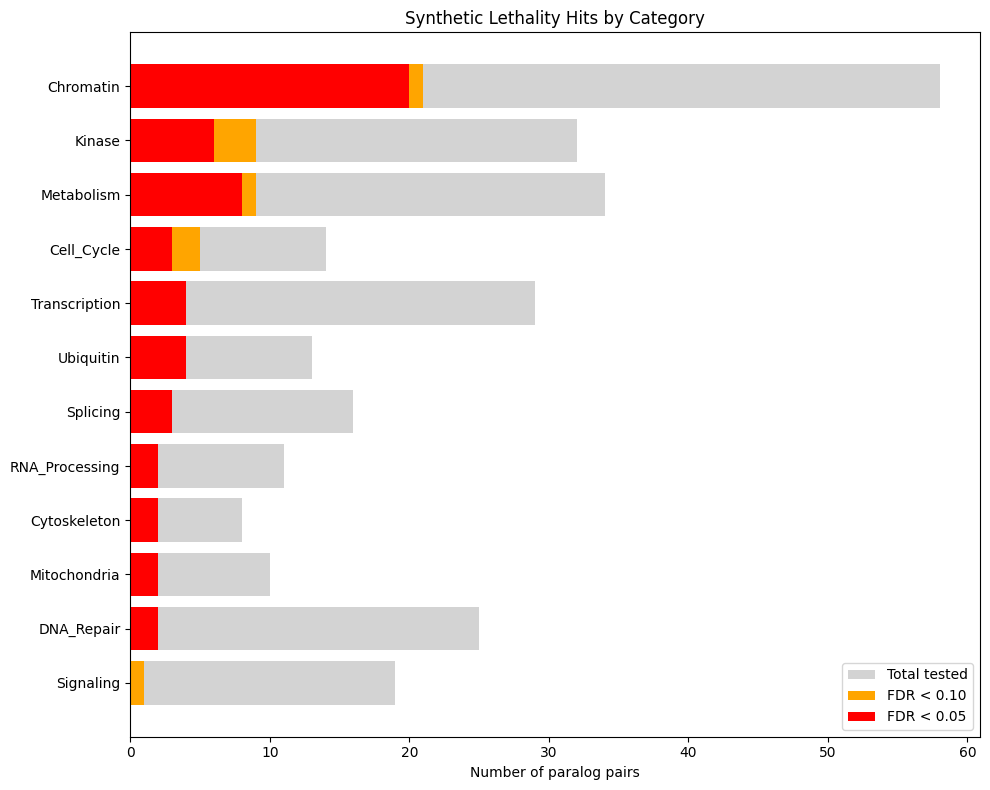

In [ ]:
SAVE_DIR = f"{WORK_DIR}/results/by_category"

# カテゴリーサマリー
plot_category_summary(results, save_dir=SAVE_DIR)

Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_by_category.png


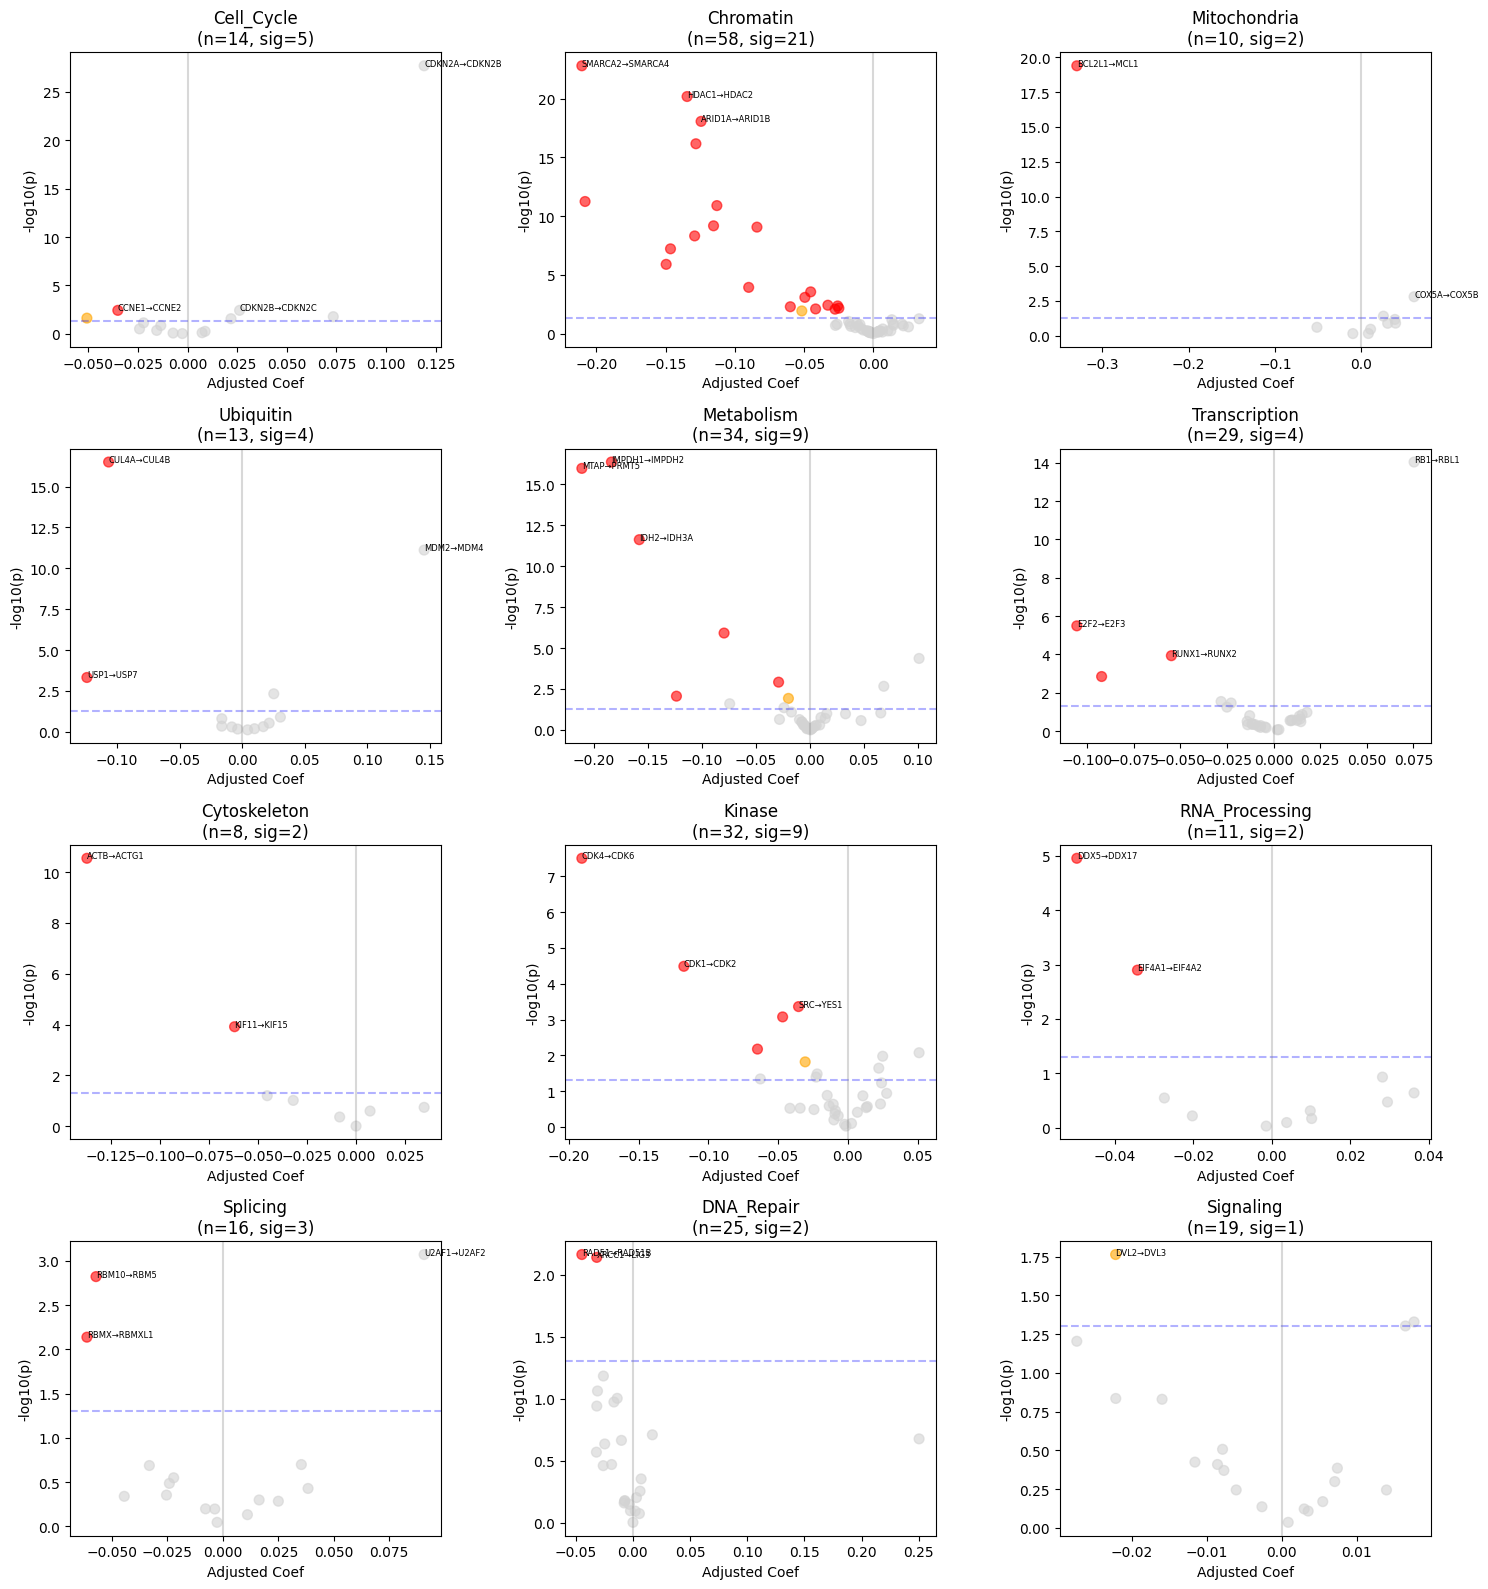

In [ ]:
# カテゴリー別Volcano
plot_volcano_by_category(results, save_dir=SAVE_DIR)

Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/top_hits_forest.png


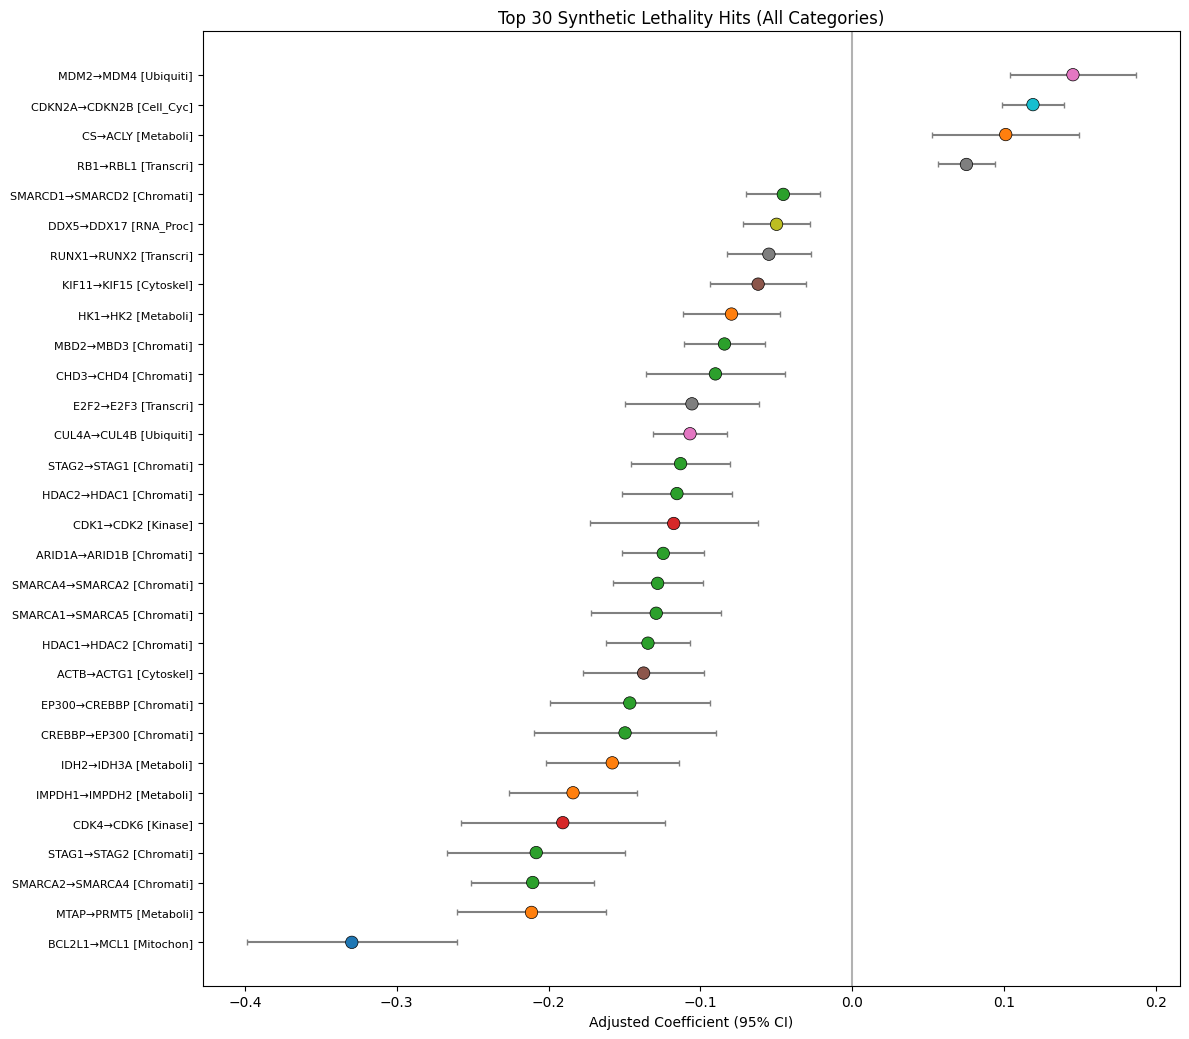

In [ ]:
# Top hits Forest plot
plot_top_hits_forest(results, n_top=30, save_dir=SAVE_DIR)

---
## 7. カテゴリー別に結果保存

In [ ]:
# 全結果保存
results.to_csv(f"{WORK_DIR}/results/all_paralog_scan_results.csv", index=False)

# FDR < 0.1 のみ
sig_results = results[results['fdr'] < 0.1]
sig_results.to_csv(f"{WORK_DIR}/results/significant_hits_fdr10_all.csv", index=False)

# カテゴリー別に保存
for cat, cat_df in scanner.results_by_category.items():
    safe_cat = re.sub(r'[^a-zA-Z0-9]', '_', cat)
    cat_df.to_csv(f"{SAVE_DIR}/{safe_cat}_results.csv", index=False)

    # 有意なもののみも保存
    sig_cat = cat_df[cat_df['fdr'] < 0.1]
    if len(sig_cat) > 0:
        sig_cat.to_csv(f"{SAVE_DIR}/{safe_cat}_significant.csv", index=False)

print(f"\n✅ Results saved!")
print(f"   - {WORK_DIR}/results/all_paralog_scan_results.csv ({len(results)} pairs)")
print(f"   - {WORK_DIR}/results/significant_hits_fdr10_all.csv ({len(sig_results)} hits)")
print(f"   - Category-specific files in {SAVE_DIR}/")


✅ Results saved!
   - /content/drive/MyDrive/2026/SR_paralog/results/all_paralog_scan_results.csv (269 pairs)
   - /content/drive/MyDrive/2026/SR_paralog/results/significant_hits_fdr10_all.csv (64 hits)
   - Category-specific files in /content/drive/MyDrive/2026/SR_paralog/results/by_category/


---
## 8. カテゴリー別詳細表示

In [ ]:
# 各カテゴリーのTop hits を表示
for cat in sorted(results['category'].unique()):
    cat_df = results[results['category'] == cat]
    sig_count = cat_df['significant_fdr10'].sum()

    print(f"\n{'='*70}")
    print(f"📂 {cat} (Tested: {len(cat_df)}, Significant FDR<0.1: {sig_count})")
    print(f"{'='*70}")

    if sig_count > 0:
        display(cat_df[cat_df['fdr'] < 0.1][['driver_gene', 'target_gene', 'subcategory',
                                              'n_affected', 'adjusted_coef', 'fdr', 'evidence']])
    else:
        print("   No significant hits at FDR < 0.1")
        print("   Top 3 pairs:")
        display(cat_df.head(3)[['driver_gene', 'target_gene', 'subcategory',
                                'n_affected', 'adjusted_coef', 'adjusted_pvalue']])


📂 Cell_Cycle (Tested: 14, Significant FDR<0.1: 5)


,driver_gene,target_gene,subcategory,n_affected,adjusted_coef,fdr,evidence
214,CDKN2A,CDKN2B,CDKI,434,0.119177,5.826224e-26,published
215,CDKN2B,CDKN2C,CDKI,319,0.026190,2.318294e-02,predicted
211,CCNE1,CCNE2,Cyclin,280,-0.035154,2.318294e-02,predicted
217,BUB1,BUB1B,SAC,243,0.073397,7.265792e-02,predicted
209,CCND1,CCND2,Cyclin,235,-0.050731,9.852894e-02,predicted



📂 Chromatin (Tested: 58, Significant FDR<0.1: 21)


,driver_gene,target_gene,subcategory,n_affected,adjusted_coef,fdr,evidence
1,SMARCA2,SMARCA4,SWI/SNF,353,-0.210436,2.130554e-21,published
29,HDAC1,HDAC2,NuRD,246,-0.134501,5.876839e-19,published
2,ARID1A,ARID1B,SWI/SNF,365,-0.124411,4.613120e-17,published
0,SMARCA4,SMARCA2,SWI/SNF,338,-0.128123,2.313249e-15,published
47,STAG1,STAG2,Cohesin,295,-0.208107,1.272563e-10,published
48,STAG2,STAG1,Cohesin,290,-0.113009,2.431783e-10,published
30,HDAC2,HDAC1,NuRD,282,-0.115406,1.121253e-08,published
32,MBD2,MBD3,NuRD,299,-0.084082,1.365735e-08,predicted
53,SMARCA1,SMARCA5,ISWI,259,-0.129042,7.241374e-08,predicted
34,EP300,CREBBP,HAT,368,-0.146462,8.150212e-07,published



📂 Cytoskeleton (Tested: 8, Significant FDR<0.1: 2)


...

,driver_gene,target_gene,subcategory,n_affected,adjusted_coef,fdr,evidence
119,U2AF1,U2AF2,U2AF,262,0.090772,0.006506,published
131,RBM10,RBM5,RBM,278,-0.057262,0.010366,predicted
132,RBMX,RBMXL1,RBM,255,-0.061364,0.037602,predicted



📂 Transcription (Tested: 29, Significant FDR<0.1: 4)


,driver_gene,target_gene,subcategory,n_affected,adjusted_coef,fdr,evidence
152,RB1,RBL1,RB_family,299,0.075343,2.479802e-13,predicted
155,E2F2,E2F3,E2F,253,-0.105514,3.801936e-05,predicted
142,RUNX1,RUNX2,RUNX,303,-0.054802,1.120739e-03,predicted
139,YAP1,WWTR1,Hippo,236,-0.092207,1.013728e-02,published



📂 Ubiquitin (Tested: 13, Significant FDR<0.1: 4)


,driver_gene,target_gene,subcategory,n_affected,adjusted_coef,fdr,evidence
199,CUL4A,CUL4B,Cullin,296,-0.106779,1.429759e-15,predicted
194,MDM2,MDM4,E3_ligase,333,0.145516,1.589484e-10,published
203,USP1,USP7,DUB,250,-0.124137,3.974768e-03,predicted
200,BIRC2,BIRC3,E3_ligase,271,0.025290,2.734952e-02,predicted


---
## 9. まとめ

### 解析カテゴリー
| カテゴリー | 内容 |
|-----------|------|
| Chromatin | SWI/SNF, PRC, NuRD, HAT, HMT, KDM, Cohesin |
| Metabolism | Glycolysis, TCA, Glutamine, Lipid, Nucleotide |
| DNA_Repair | HR, PARP, BER, MMR, NHEJ, FA, Checkpoint |
| Splicing | SF3B, U2AF, SRSF, hnRNP, snRNP |
| Transcription | MYC, TEAD, SMAD, RUNX, GATA, FOX, p53, RB, E2F |
| Kinase | CDK, MAPK, PI3K, RTK, Aurora, PLK, SRC |
| Ubiquitin | E3 ligase, Cullin, TRIM, DUB |
| Cell_Cycle | Cyclin, CDKI, SAC, APC |
| RNA_Processing | DDX, RNAP, Translation, Ribosome |
| Mitochondria | Complex I-V, Fusion, Fission, Apoptosis |
| Cytoskeleton | Actin, Tubulin, Kinesin, Dynein |
| Signaling | Wnt, Notch, Hedgehog, NFkB, RAS |

In [ ]:
# カテゴリー別に個別のVolcano plotを保存
def plot_volcano_individual(results, save_dir):
    """各カテゴリーのVolcano plotを個別PNGとして保存"""

    categories = results['category'].unique()

    for cat in categories:
        df = results[results['category'] == cat].copy()
        df['neg_log_p'] = -np.log10(df['adjusted_pvalue'])

        fig, ax = plt.subplots(figsize=(10, 8))

        # 色分け
        colors = ['red' if (fdr < 0.05 and c < -0.05) else
                  'orange' if (fdr < 0.1 and c < -0.05) else 'lightgray'
                  for fdr, c in zip(df['fdr'], df['adjusted_coef'])]

        ax.scatter(df['adjusted_coef'], df['neg_log_p'], c=colors, alpha=0.7, s=100,
                   edgecolors='black', linewidths=0.5)

        # 有意なヒットにラベル
        for _, row in df[df['fdr'] < 0.1].iterrows():
            ax.annotate(f"{row['driver_gene']}->{row['target_gene']}\n({row['subcategory']})",
                       (row['adjusted_coef'], row['neg_log_p']),
                       fontsize=9, fontweight='bold' if row['fdr'] < 0.05 else 'normal',
                       ha='center', va='bottom')

        ax.axhline(-np.log10(0.05), color='blue', linestyle='--', alpha=0.5, label='p=0.05')
        ax.axvline(0, color='gray', linestyle='-', alpha=0.3)

        ax.set_xlabel('Adjusted Coefficient (Confounder-corrected)', fontsize=12)
        ax.set_ylabel('-log10(p-value)', fontsize=12)
        ax.set_title(f'{cat} - Paralog Synthetic Lethality\n(n={len(df)}, FDR<0.1: {(df["fdr"]<0.1).sum()})',
                     fontsize=14, fontweight='bold')
        ax.legend(loc='upper right')

        ax.grid(True, alpha=0.3)

        plt.tight_layout()

        safe_cat = re.sub(r'[^a-zA-Z0-9]', '_', cat)
        filepath = f"{save_dir}/volcano_{safe_cat}.png"
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        print(f"Saved: {filepath}")
        plt.close()

    print(f"\nDone! {len(categories)} individual volcano plots saved!")


# 実行
SAVE_DIR = f"{WORK_DIR}/results/by_category"
plot_volcano_individual(results, SAVE_DIR)

Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Cell_Cycle.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Chromatin.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Mitochondria.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Ubiquitin.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Metabolism.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Transcription.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Cytoskeleton.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Kinase.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_RNA_Processing.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_Splicing.png
Saved: /content/drive/MyDrive/2026/SR_paralog/results/by_category/volcano_DNA_Repair.png
Saved: /content/dr

🚀 Running Advanced IMPDH Analysis

🏆 Top 20 IMPDH2 Dependent Lung Cancer Lines (Corrected KRAS):


,CellLineName,Subtype,IMPDH2_Dependency,KRAS_Detail,SCLC_Subtype,ASCL1_Expr,MYC_Expr
111,NCI-H1993,Non-Small Cell Lung Cancer,-1.829908,WT,NSCLC/Other,NaN,NaN
94,HCC515,Non-Small Cell Lung Cancer,-1.808740,p.G13D,NSCLC/Other,0.000000,6.190392
43,NCI-H1836,Lung Neuroendocrine Tumor,-1.729551,WT,NSCLC/Other,9.140843,0.203831
72,NCI-H727,Lung Neuroendocrine Tumor,-1.493406,p.G12V,NSCLC/Other,6.920853,5.255512
29,RERF-LC-Sq1,Non-Small Cell Lung Cancer,-1.384922,WT,NSCLC/Other,0.151525,5.133111
80,NCI-H322,Non-Small Cell Lung Cancer,-1.243316,WT,NSCLC/Other,0.035970,4.892682
81,HCC-366,Non-Small Cell Lung Cancer,-1.210902,WT,NSCLC/Other,0.000000,5.849784
17,NCI-H3122,Non-Small Cell Lung Cancer,-1.202300,WT,NSCLC/Other,0.008818,5.987671
104,NCI-H157-DM,Non-Small Cell Lung Cancer,-1.179831,p.G12R,NSCLC/Other,0.000000,5.826960
16,NCI-H2122,Non-Small Cell Lung Cancer,-1.144967,p.G12C,NSCLC/Other,0.090578,7.189073



📊 SCLC Subtype Analysis:


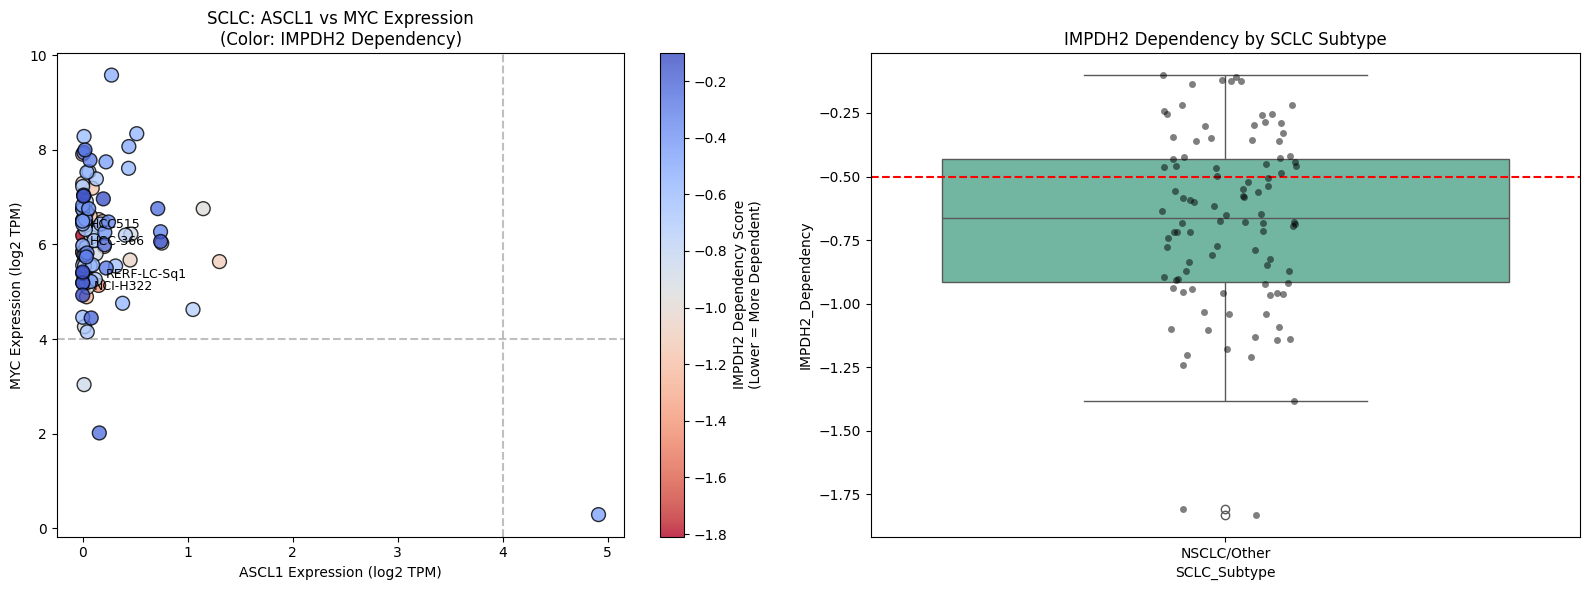

In [ ]:
# ============================================================================
# Advanced IMPDH Analyzer (Drug Sensitivity + Improved Mutation + SCLC Subtyping)
# ============================================================================

class AdvancedIMPDHAnalyzer:
    def __init__(self, loader, work_dir):
        self.loader = loader
        self.work_dir = work_dir
        self.results = None
        self.drug_data = None

    def load_drug_data(self, filename='Prism_Drug_Response.csv'):
        """薬剤感受性データの読み込み (PRISM/GDSC)"""
        # 一般的なファイル名を探索
        potential_files = [
            filename,
            'PRISM_Repurposing_Public_23Q2_Extended_Primary_Data_Matrix.csv',
            'PRISM_Repurposing_Secondary_Screen_23Q2_Subset_Log_Fold_Change.csv',
            'GDSC2_fitted_dose_response_25Feb20.csv'
        ]

        found_path = None
        for f in potential_files:
            p = Path(self.loader.data_dir) / f
            if p.exists():
                found_path = p
                break

        if found_path:
            print(f"💊 Loading Drug Data from: {found_path.name} ...")
            try:
                # PRISMデータは通常 (ModelID x Drug) のマトリックス または Long format
                df = pd.read_csv(found_path, index_col=0)
                # マトリックス形式かどうかで処理を分ける（ここでは簡易的にModelIDがインデックスと仮定）
                self.drug_data = df
                print(f"   ✅ Loaded {df.shape[0]} cell lines x {df.shape[1]} drugs")
            except Exception as e:
                print(f"   ⚠️ Failed to load drug data: {e}")
        else:
            print("⚠️ No Drug Sensitivity file found in data directory.")
            print("   (To analyze drugs, upload 'Prism_Drug_Response.csv' to the data folder)")

    def get_kras_status(self, model_id):
        """KRAS変異情報の取得ロジック改良版"""
        if self.loader.mutations is None:
            return False, "Unknown"

        # KRASの変異を抽出 (Silent以外)
        muts = self.loader.mutations[
            (self.loader.mutations['ModelID'] == model_id) &
            (self.loader.mutations['HugoSymbol'] == 'KRAS')
        ]

        # 'Silent' を除外 (VariantInfoカラムが存在する場合)
        if 'VariantInfo' in muts.columns:
            muts = muts[~muts['VariantInfo'].str.contains('SILENT|Silent', case=False, na=False)]

        if len(muts) > 0:
            # 変異詳細を取得 (HGVSp_Short > ProteinChange > VariantInfo の優先順位)
            if 'HGVSp_Short' in muts.columns:
                detail = muts.iloc[0]['HGVSp_Short']
            elif 'ProteinChange' in muts.columns:
                detail = muts.iloc[0]['ProteinChange']
            else:
                detail = muts.iloc[0].get('VariantInfo', 'Mutant')
            return True, detail

        return False, "WT"

    def analyze(self):
        print("="*60)
        print("🚀 Running Advanced IMPDH Analysis")
        print("="*60)

        # 1. 肺癌細胞株抽出
        lung_models = self.loader.model[self.loader.model['OncotreeLineage'] == 'Lung'].copy()
        valid_models = [m for m in lung_models.index if m in self.loader.crispr.index]

        data_list = []
        target_genes = ['IMPDH1', 'IMPDH2']
        biomarkers = ['MYC', 'ASCL1', 'NEUROD1', 'POU2F3', 'YAP1'] # SCLC Subtypes

        for model_id in valid_models:
            row = {
                'ModelID': model_id,
                'CellLineName': lung_models.loc[model_id, 'CellLineName'],
                'Subtype': lung_models.loc[model_id, 'OncotreePrimaryDisease'],
            }

            # CRISPR Dependency
            for gene in target_genes:
                if gene in self.loader.crispr.columns:
                    row[f'{gene}_Dependency'] = self.loader.crispr.loc[model_id, gene]

            # Expression
            if self.loader.expression is not None and model_id in self.loader.expression.index:
                for gene in biomarkers:
                    if gene in self.loader.expression.columns:
                        row[f'{gene}_Expr'] = self.loader.expression.loc[model_id, gene]

            # Improved KRAS Status
            is_mut, detail = self.get_kras_status(model_id)
            row['KRAS_Mutant'] = is_mut
            row['KRAS_Detail'] = detail

            # Drug Sensitivity (IMPDH inhibitors)
            if self.drug_data is not None and model_id in self.drug_data.index:
                # ターゲットとなりそうな薬剤名の一部
                drug_keywords = ['Mycophenolic', 'Mizoribine', 'Ribavirin', 'Tiazofurin']
                for drug_col in self.drug_data.columns:
                    for kw in drug_keywords:
                        if kw.lower() in drug_col.lower():
                            # 列名に薬剤名が含まれていれば取得
                            row[f'Drug_{kw}'] = self.drug_data.loc[model_id, drug_col]

            data_list.append(row)

        self.results = pd.DataFrame(data_list)

        # SCLCのサブタイプ分類 (簡易版)
        def classify_sclc(row):
            if row['Subtype'] != 'Small Cell Lung Cancer':
                return 'NSCLC/Other'

            # 発現データがない場合
            if pd.isna(row.get('ASCL1_Expr')): return 'SCLC-Unknown'

            # ASCL1 vs MYC
            # (厳密な定義は複雑ですが、ここでは相対的な高低で分類)
            if row['ASCL1_Expr'] > 4 and row['MYC_Expr'] < 4:
                return 'SCLC-A (ASCL1-high)'
            elif row['ASCL1_Expr'] < 4 and row['MYC_Expr'] > 4:
                return 'SCLC-Y/M (MYC-high)' # 簡易的にMYC高発現群
            else:
                return 'SCLC-Other' # Double positive / Double negative

        self.results['SCLC_Subtype'] = self.results.apply(classify_sclc, axis=1)

        if 'IMPDH2_Dependency' in self.results.columns:
            self.results = self.results.sort_values('IMPDH2_Dependency', ascending=True)

        return self.results

    def plot_sclc_analysis(self):
        """SCLCにおけるASCL1 vs MYC と IMPDH2依存性の可視化"""
        sclc_df = self.results[self.results['Subtype'].str.contains('Small Cell', case=False, na=False)].copy()

        if len(sclc_df) < 5:
            print("Not enough SCLC cell lines for plotting.")
            return

        fig, ax = plt.subplots(1, 2, figsize=(16, 6))

        # 1. Scatter Plot: ASCL1 vs MYC (Color: IMPDH2 Dependency)
        sc = ax[0].scatter(sclc_df['ASCL1_Expr'], sclc_df['MYC_Expr'],
                          c=sclc_df['IMPDH2_Dependency'], cmap='coolwarm_r',
                          s=100, edgecolors='k', alpha=0.8)
        ax[0].set_xlabel('ASCL1 Expression (log2 TPM)')
        ax[0].set_ylabel('MYC Expression (log2 TPM)')
        ax[0].set_title('SCLC: ASCL1 vs MYC Expression\n(Color: IMPDH2 Dependency)')
        ax[0].axhline(4, linestyle='--', color='gray', alpha=0.5)
        ax[0].axvline(4, linestyle='--', color='gray', alpha=0.5)
        plt.colorbar(sc, ax=ax[0], label='IMPDH2 Dependency Score\n(Lower = More Dependent)')

        # Top hitsのラベル表示
        top_deps = sclc_df.nsmallest(5, 'IMPDH2_Dependency')
        for _, row in top_deps.iterrows():
            ax[0].annotate(row['CellLineName'], (row['ASCL1_Expr'], row['MYC_Expr']),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)

        # 2. Box Plot: Subtype vs Dependency
        sns.boxplot(data=sclc_df, x='SCLC_Subtype', y='IMPDH2_Dependency', ax=ax[1], palette='Set2')
        sns.stripplot(data=sclc_df, x='SCLC_Subtype', y='IMPDH2_Dependency', ax=ax[1], color='black', alpha=0.5)
        ax[1].set_title('IMPDH2 Dependency by SCLC Subtype')
        ax[1].axhline(-0.5, color='red', linestyle='--', label='Strong Dep.')

        plt.tight_layout()
        plt.show()

# --- 実行 ---
# 1. データの再読み込みが必要であれば loader を再定義、すでにメモリにあるならそのまま使用
# loader = DepMap25Q3Loader(DATA_DIR).load_all()

analyzer = AdvancedIMPDHAnalyzer(loader, WORK_DIR)

# 薬剤データがある場合はここで読み込みを試行 (ファイルがなければスキップされます)
# analyzer.load_drug_data('PRISM_Repurposing_Public_23Q2_Extended_Primary_Data_Matrix.csv')

# 解析実行
results = analyzer.analyze()

# 結果表示 1: KRAS変異を含むTop 20
print("\n🏆 Top 20 IMPDH2 Dependent Lung Cancer Lines (Corrected KRAS):")
disp_cols = ['CellLineName', 'Subtype', 'IMPDH2_Dependency', 'KRAS_Detail', 'SCLC_Subtype', 'ASCL1_Expr', 'MYC_Expr']
if 'Drug_Mycophenolic' in results.columns:
    disp_cols.append('Drug_Mycophenolic') # 薬剤データがあれば表示

display(results[disp_cols].head(20))

# 結果表示 2: SCLC解析プロット
print("\n📊 SCLC Subtype Analysis:")
analyzer.plot_sclc_analysis()

# 保存
results.to_csv(f"{WORK_DIR}/results/lung_impdh2_advanced_analysis.csv", index=False)

💊 Loading PRISM Data from: /content/drive/MyDrive/2026/SR_paralog/Prism_Drug_Response.csv
   ✅ Loaded 701004 rows.
🚀 Running Analysis (Auto-detecting columns...)
   ℹ️ Using mutation column: ProteinChange

🏆 Top 20 IMPDH2 Dependent Lines with Mycophenolic Acid Sensitivity:


,CellLineName,Subtype,IMPDH2_Dependency,Mycophenolic Acid_Log2_IC50,KRAS_Detail
111,NCI-H1993,Non-Small Cell Lung Cancer,-1.829908,NaN,WT
94,HCC515,Non-Small Cell Lung Cancer,-1.808740,NaN,p.G13D
43,NCI-H1836,Lung Neuroendocrine Tumor,-1.729551,NaN,WT
72,NCI-H727,Lung Neuroendocrine Tumor,-1.493406,0.848754,p.G12V
29,RERF-LC-Sq1,Non-Small Cell Lung Cancer,-1.384922,NaN,WT
80,NCI-H322,Non-Small Cell Lung Cancer,-1.243316,0.842307,WT
81,HCC-366,Non-Small Cell Lung Cancer,-1.210902,0.950611,WT
17,NCI-H3122,Non-Small Cell Lung Cancer,-1.202300,NaN,WT
104,NCI-H157-DM,Non-Small Cell Lung Cancer,-1.179831,1.265231,p.G12R
16,NCI-H2122,Non-Small Cell Lung Cancer,-1.144967,0.737701,p.G12C


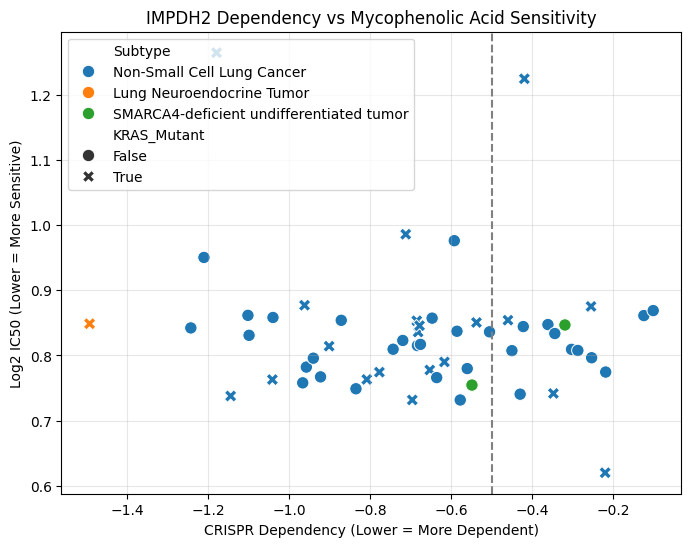

In [ ]:
# ============================================================================
# 修正・決定版: PRISM & Mutation 解析コード (列名自動判別機能付き)
# ============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class PrismAwareAnalyzer:
    def __init__(self, loader, work_dir):
        self.loader = loader
        self.work_dir = work_dir
        self.results = None
        self.drug_df = None

    def load_prism_data(self, filename='Prism_Drug_Response.csv'):
        """PRISMデータの読み込み (パス探索強化版)"""
        # 探す場所の候補
        search_paths = [
            filename,                                      # そのまま指定
            f"/content/{filename}",                        # Colabルート
            f"{self.work_dir}/{filename}",                 # 作業ディレクトリ
            f"{self.loader.data_dir}/{filename}",          # データディレクトリ
            "Prism_Drug_Response.csv",                     # デフォルト名
            "secondary-screen-dose-response-curve-parameters.csv" # 元のファイル名
        ]

        found_path = None
        for p in search_paths:
            if os.path.exists(p):
                found_path = p
                break

        if found_path:
            print(f"💊 Loading PRISM Data from: {found_path}")
            try:
                self.drug_df = pd.read_csv(found_path)
                # カラム名を小文字に統一して扱いやすくする
                self.drug_df.columns = self.drug_df.columns.str.lower()
                print(f"   ✅ Loaded {len(self.drug_df)} rows.")
            except Exception as e:
                print(f"   ❌ Failed to load csv: {e}")
        else:
            print(f"⚠️ PRISM file '{filename}' NOT found in any search paths.")
            print(f"   Current Directory: {os.getcwd()}")
            print("   Please make sure the file is uploaded to /content/ or the work directory.")

    def get_drug_sensitivity(self, model_id, target_broad_id):
        if self.drug_df is None: return None

        # depmap_id と broad_id で検索
        # broad_id は部分一致 (BRD-K...-001...)
        match = self.drug_df[
            (self.drug_df['depmap_id'] == model_id) &
            (self.drug_df['broad_id'].str.contains(target_broad_id, na=False))
        ]

        if len(match) > 0:
            # log2.ic50 があれば優先、なければ auc
            if 'log2.ic50' in match.columns:
                return match.iloc[0]['log2.ic50']
            elif 'auc' in match.columns:
                return match.iloc[0]['auc']
        return None

    def analyze(self):
        print("="*60)
        print("🚀 Running Analysis (Auto-detecting columns...)")
        print("="*60)

        # --- Mutation列名の自動判別 ---
        mut_cols = self.loader.mutations.columns
        protein_col = 'HGVSp_Short' # Default
        if 'HGVSp_Short' not in mut_cols:
            if 'ProteinChange' in mut_cols:
                protein_col = 'ProteinChange'
            elif 'HGVSp' in mut_cols:
                protein_col = 'HGVSp'
            else:
                protein_col = None
                print("   ⚠️ Warning: No Protein Change column found (checked HGVSp_Short, ProteinChange, HGVSp).")

        print(f"   ℹ️ Using mutation column: {protein_col}")

        # ターゲット薬剤: Mycophenolic Acid
        TARGET_DRUG_ID = "BRD-K63750851"
        TARGET_DRUG_NAME = "Mycophenolic Acid"

        # 肺癌細胞株抽出
        lung_models = self.loader.model[self.loader.model['OncotreeLineage'] == 'Lung'].copy()
        valid_models = [m for m in lung_models.index if m in self.loader.crispr.index]

        data_list = []

        for model_id in valid_models:
            row = {
                'ModelID': model_id,
                'CellLineName': lung_models.loc[model_id, 'CellLineName'],
                'Subtype': lung_models.loc[model_id, 'OncotreePrimaryDisease'],
            }

            # CRISPR
            if 'IMPDH2' in self.loader.crispr.columns:
                row['IMPDH2_Dependency'] = self.loader.crispr.loc[model_id, 'IMPDH2']

            # Drug Sensitivity
            if self.drug_df is not None:
                sens = self.get_drug_sensitivity(model_id, TARGET_DRUG_ID)
                row[f'{TARGET_DRUG_NAME}_Log2_IC50'] = sens

            # KRAS Status (修正版)
            if self.loader.mutations is not None:
                muts = self.loader.mutations[
                    (self.loader.mutations['ModelID'] == model_id) &
                    (self.loader.mutations['HugoSymbol'] == 'KRAS') &
                    (~self.loader.mutations['VariantInfo'].str.contains('SILENT', case=False, na=False))
                ]
                row['KRAS_Mutant'] = len(muts) > 0

                # 詳細情報の取得 (列名判別結果を使用)
                if len(muts) > 0:
                    if protein_col and protein_col in muts.columns:
                         row['KRAS_Detail'] = muts.iloc[0][protein_col]
                    else:
                         row['KRAS_Detail'] = "Mutant (No Info)"
                else:
                    row['KRAS_Detail'] = 'WT'

            data_list.append(row)

        self.results = pd.DataFrame(data_list)
        if 'IMPDH2_Dependency' in self.results.columns:
            self.results = self.results.sort_values('IMPDH2_Dependency', ascending=True)

        return self.results

# --- 実行 ---
prism_analyzer = PrismAwareAnalyzer(loader, WORK_DIR)

# ファイル名を指定してロード (アップロードしたファイル名に合わせてください)
prism_analyzer.load_prism_data('Prism_Drug_Response.csv')

final_results = prism_analyzer.analyze()

# 結果表示
print("\n🏆 Top 20 IMPDH2 Dependent Lines with Mycophenolic Acid Sensitivity:")
cols = ['CellLineName', 'Subtype', 'IMPDH2_Dependency', 'Mycophenolic Acid_Log2_IC50', 'KRAS_Detail']
display_cols = [c for c in cols if c in final_results.columns]
display(final_results[display_cols].head(20))

# 散布図
if 'Mycophenolic Acid_Log2_IC50' in final_results.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=final_results, x='IMPDH2_Dependency', y='Mycophenolic Acid_Log2_IC50',
                    hue='Subtype', style='KRAS_Mutant', s=80)
    plt.title('IMPDH2 Dependency vs Mycophenolic Acid Sensitivity')
    plt.xlabel('CRISPR Dependency (Lower = More Dependent)')
    plt.ylabel('Log2 IC50 (Lower = More Sensitive)')
    plt.axvline(-0.5, color='gray', linestyle='--')
    plt.grid(True, alpha=0.3)
    plt.show()

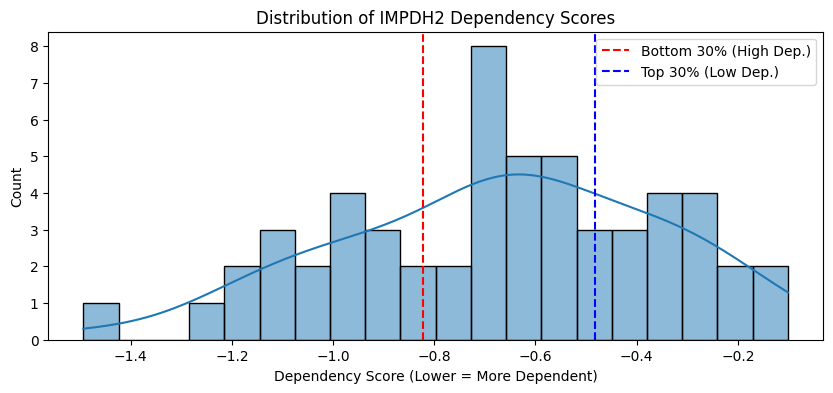

閾値 (High Dep): score <= -0.822 (n=17)
閾値 (Low Dep) : score >= -0.483 (n=17)


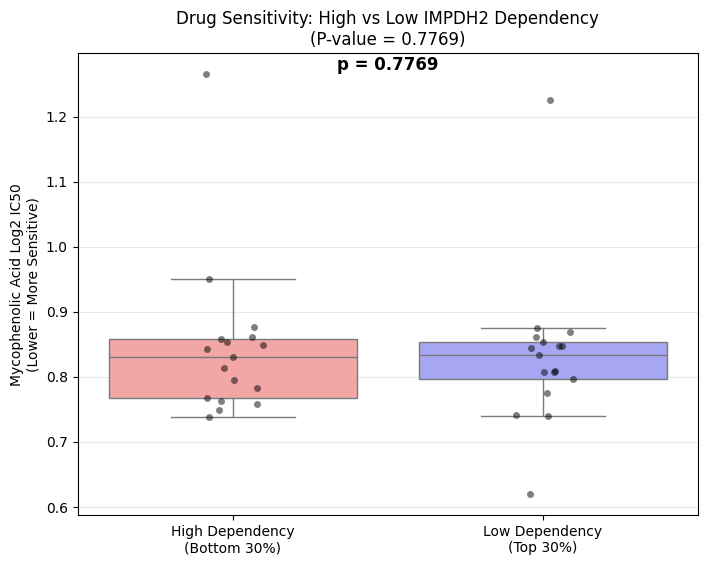

In [ ]:
# ============================================================================
# 修正版: 分位点（Quantile）を用いた統計解析 & ヒストグラム
# ============================================================================

def analyze_sensitivity_by_quantile(results_df, drug_col, quantile_pct=0.30):
    """上位・下位30%で群分けして比較"""
    df = results_df.dropna(subset=['IMPDH2_Dependency', drug_col]).copy()

    # 分布を確認するためのヒストグラム
    plt.figure(figsize=(10, 4))
    sns.histplot(df['IMPDH2_Dependency'], bins=20, kde=True)
    plt.axvline(df['IMPDH2_Dependency'].quantile(quantile_pct), color='red', linestyle='--', label=f'Bottom {int(quantile_pct*100)}% (High Dep.)')
    plt.axvline(df['IMPDH2_Dependency'].quantile(1-quantile_pct), color='blue', linestyle='--', label=f'Top {int(quantile_pct*100)}% (Low Dep.)')
    plt.title('Distribution of IMPDH2 Dependency Scores')
    plt.legend()
    plt.xlabel('Dependency Score (Lower = More Dependent)')
    plt.show()

    # 群分け (Quantile base)
    # 下位30% = スコアが低い = 依存度が高い (High Dependency)
    # 上位30% = スコアが高い = 依存度が低い (Low Dependency)
    th_low = df['IMPDH2_Dependency'].quantile(quantile_pct)
    th_high = df['IMPDH2_Dependency'].quantile(1 - quantile_pct)

    high_dep_group = df[df['IMPDH2_Dependency'] <= th_low]
    low_dep_group = df[df['IMPDH2_Dependency'] >= th_high]

    print(f"閾値 (High Dep): score <= {th_low:.3f} (n={len(high_dep_group)})")
    print(f"閾値 (Low Dep) : score >= {th_high:.3f} (n={len(low_dep_group)})")

    # T検定
    t_stat, p_val = stats.ttest_ind(high_dep_group[drug_col], low_dep_group[drug_col], equal_var=False)

    # Boxplot
    plot_data = pd.concat([
        high_dep_group.assign(Group='High Dependency\n(Bottom 30%)'),
        low_dep_group.assign(Group='Low Dependency\n(Top 30%)')
    ])

    plt.figure(figsize=(8, 6))
    sns.boxplot(data=plot_data, x='Group', y=drug_col, palette=['#ff9999', '#9999ff'], showfliers=False)
    sns.stripplot(data=plot_data, x='Group', y=drug_col, color='black', alpha=0.5)

    plt.title(f'Drug Sensitivity: High vs Low IMPDH2 Dependency\n(P-value = {p_val:.4f})')
    plt.ylabel('Mycophenolic Acid Log2 IC50\n(Lower = More Sensitive)')
    plt.xlabel('')

    # 有意差表示
    max_y = plot_data[drug_col].max()
    min_y = plot_data[drug_col].min()
    plt.text(0.5, max_y, f'p = {p_val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- 実行 ---
drug_column = 'Mycophenolic Acid_Log2_IC50'
if drug_column in final_results.columns:
    analyze_sensitivity_by_quantile(final_results, drug_column, quantile_pct=0.30)

🧪 Screening Multiple IMPDH Inhibitors
✅ mycophenolic-acid (n=56)
   - Correlation R: -0.133
   - T-test P-value: 0.7769


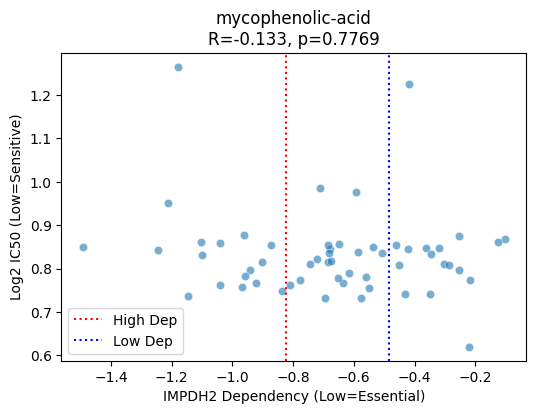

⚠️ Drug not found: Mizoribine
✅ ribavirin (n=62)
   - Correlation R: 0.021
   - T-test P-value: 0.8301


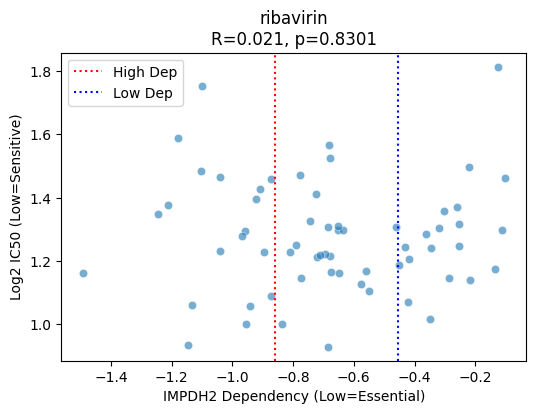

✅ cytarabine (n=55)
   - Correlation R: 0.055
   - T-test P-value: 0.5418


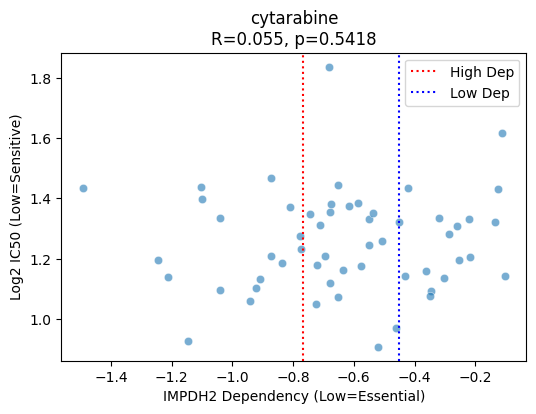

✅ cytarabine (n=55)
   - Correlation R: 0.055
   - T-test P-value: 0.5418


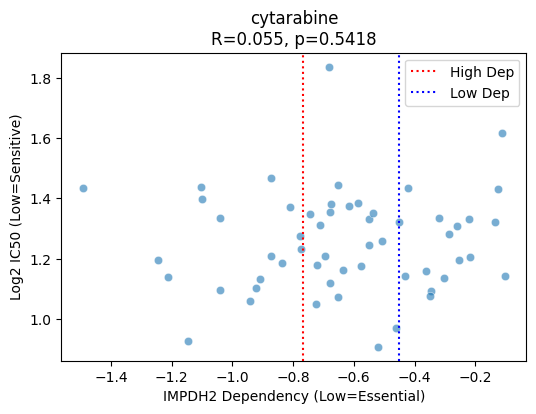

In [ ]:
# ============================================================================
# 複数のIMPDH阻害剤を一括検証するコード
# ============================================================================

def analyze_multiple_drugs(prism_analyzer):
    print("="*60)
    print("🧪 Screening Multiple IMPDH Inhibitors")
    print("="*60)

    # 検証したい薬剤リスト (Broad IDの一部 または 名前)
    # PortalCompounds.csv で確認した薬剤
    target_drugs = [
        {"name": "Mycophenolic Acid", "id": "BRD-K63750851"}, # さっきの結果
        {"name": "Mizoribine", "id": "BRD-A95032015"},       # IDは推定（名前検索します）
        {"name": "Ribavirin", "id": "BRD-K70278783"},
        {"name": "Tiazofurin", "id": "BRD-K"},               # 部分一致検索
        {"name": "Merimepodib", "id": "BRD-K"}
    ]

    # データフレーム準備
    results = []

    if prism_analyzer.drug_df is None:
        print("Error: Drug data not loaded.")
        return

    # 全細胞株のデータを取得
    lung_models = prism_analyzer.loader.model[prism_analyzer.loader.model['OncotreeLineage'] == 'Lung'].index
    valid_models = [m for m in lung_models if m in prism_analyzer.loader.crispr.index]

    # 薬剤ごとにループ
    for drug in target_drugs:
        drug_name = drug['name']
        search_id = drug['id']

        # 薬剤IDがデータ内にあるか検索
        # broad_id列から検索
        matched_rows = prism_analyzer.drug_df[
            prism_analyzer.drug_df['broad_id'].str.contains(search_id, na=False) |
            prism_analyzer.drug_df['name'].str.contains(drug_name, case=False, na=False)
        ]

        if len(matched_rows) == 0:
            print(f"⚠️ Drug not found: {drug_name}")
            continue

        # 実際に使われているBroad IDを取得 (複数ある場合は最初のもの)
        real_broad_id = matched_rows.iloc[0]['broad_id']
        real_drug_name = matched_rows.iloc[0]['name']

        # 解析用データ作成
        df_list = []
        for model_id in valid_models:
            if 'IMPDH2' not in prism_analyzer.loader.crispr.columns: continue

            dep = prism_analyzer.loader.crispr.loc[model_id, 'IMPDH2']
            sens = prism_analyzer.get_drug_sensitivity(model_id, real_broad_id)

            if sens is not None:
                df_list.append({'ModelID': model_id, 'Dep': dep, 'Sens': sens})

        df = pd.DataFrame(df_list)

        if len(df) < 10:
            print(f"⚠️ Not enough data for {drug_name} (n={len(df)})")
            continue

        # 相関係数 (全体)
        corr, p_corr = stats.pearsonr(df['Dep'], df['Sens'])

        # 上位・下位30%比較 (T検定)
        th_low = df['Dep'].quantile(0.30)
        th_high = df['Dep'].quantile(0.70)
        high_group = df[df['Dep'] <= th_low]['Sens']
        low_group = df[df['Dep'] >= th_high]['Sens']

        t_stat, p_ttest = stats.ttest_ind(high_group, low_group, equal_var=False)

        print(f"✅ {real_drug_name} (n={len(df)})")
        print(f"   - Correlation R: {corr:.3f}")
        print(f"   - T-test P-value: {p_ttest:.4f}")

        # 散布図を描画
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x='Dep', y='Sens', alpha=0.6)
        plt.title(f"{real_drug_name}\nR={corr:.3f}, p={p_ttest:.4f}")
        plt.xlabel("IMPDH2 Dependency (Low=Essential)")
        plt.ylabel("Log2 IC50 (Low=Sensitive)")
        plt.axvline(th_low, color='red', linestyle=':', label='High Dep')
        plt.axvline(th_high, color='blue', linestyle=':', label='Low Dep')
        plt.legend()
        plt.show()

# --- 実行 ---
analyze_multiple_drugs(prism_analyzer)